# Data Loading and Preprocessing

The following cell initializes our analysis environment and loads the simulation datasets. It defines a function to read the individual CSV files for each ship, appends identifying suffixes to the columns, and merges them into a single time-aligned dataset. Finally, it automates the import process by looping through the specified simulation folders and organizing the merged data into a dictionary for easy side-by-side comparison.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import os

In [4]:
def load_simulation_data(file_paths_dict):
    ### first we do this: create an empty list to store our dataframes
    dfs = []

    ### next we loop through all the items in the provided dictionary
    for ship_name, file_path in file_paths_dict.items():
        ### load the CSV file using the provided file path
        df = pd.read_csv(file_path)
        
        ### add a suffix to all columns except time_s to identify the ship
        df = df.add_suffix(f'_{ship_name}')
        df.rename(columns={f'time_s_{ship_name}': 'time_s'}, inplace=True)
        
        dfs.append(df)
    
    ### then  check if we have any dataframes to merge
    if not dfs:
        return pd.DataFrame()
        
    ###  start the merged dataframe with the first one in the list
    merged_df = dfs[0]
    
    ### finally  merge the rest of the dataframes one by one on time_s
    for df in dfs[1:]:
        merged_df = pd.merge(merged_df, df, on='time_s', how='outer')
    
    return merged_df

### print a separator before our output
print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

### first define the base folder of our choosing
base_folder = 'Scenario_4'

### next  dynamically find all subfolders inside the base folder
folder_names = [os.path.join(base_folder, name) for name in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, name))]

### next set up the empty dictionary to store the results
simulations = {}

### then loop through each folder name in our list
for folder in folder_names:
    
    ### construct the paths dynamically using f-strings
    ### use double backslashes (\\) so Python reads it as a single backslash in the path
    simulations[folder] = load_simulation_data({
        'Holding_Course_Ship': f'{folder}\\Holding_Course_Ship.csv',
        'Yielding_Ship': f'{folder}\\Yielding_Ship.csv'
    })

print("All simulation data loaded successfully!")
print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
All simulation data loaded successfully!
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [5]:
### extract all the keys from the dictionary and convert them to a list to get the first one
first_folder = list(simulations.keys())[0]

### next use that folder name to access the corresponding dataframe
first_df = simulations[first_folder]

print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
print(f"First dataset loaded from: {first_folder}")
print(first_df.head())
print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
First dataset loaded from: Scenario_4\DS_S4-01_60_min_T-10
   time_s  x_m_Holding_Course_Ship  y_m_Holding_Course_Ship  \
0     5.0                      0.0                 -3982.14   
1     6.0                      0.0                 -3977.47   
2     7.0                      0.0                 -3972.84   
3     8.0                      0.0                 -3968.26   
4     9.0                      0.0                 -3963.72   

   course_deg_Holding_Course_Ship  speed_ms_Holding_Course_Ship  \
0                             0.0                         4.715   
1                             0.0                         4.670   
2                             0.0                         4.627   
3                             0.0                         4.584   
4                             0.0                         4.543   

   rudder_deg_Holding_Course_Ship  rpm_percent_Holding_Course_Ship  \
0                             0.0     

# Safety Analysis: Closest Point of Approach (CPA)

The following cell evaluates the safety of the executed maneuvers by calculating the Closest Point of Approach (CPA) and the Time to CPA (TCPA) for every pair of vessels. It dynamically identifies all ships present in the dataset, computes the Euclidean distance between each unique pair at every time step, and extracts the minimum distance achieved to help identify any critical near-miss situations.

In [6]:
def calculate_cpa(df):
    ### first we do this: find all unique ship names by looking at the column headers
    ship_names = [col.replace('x_m_', '') for col in df.columns if col.startswith('x_m_')]
    
    cpas = {}
    
    ### next we use itertools to generate all unique pairs of ships
    for ship_a, ship_b in itertools.combinations(ship_names, 2):
        col_x_a = f'x_m_{ship_a}'
        col_y_a = f'y_m_{ship_a}'
        col_x_b = f'x_m_{ship_b}'
        col_y_b = f'y_m_{ship_b}'
        
        ### then we calculate the distance for this specific pair
        dist_col_name = f'dist_{ship_a}_{ship_b}'
        df[dist_col_name] = np.sqrt((df[col_x_a] - df[col_x_b])**2 + (df[col_y_a] - df[col_y_b])**2)
        
        ### finally we find the minimum distance and the time it occurred
        cpa_val = df[dist_col_name].min()
        tcpa_val = df.loc[df[dist_col_name].idxmin(), 'time_s']
        
        cpas[f'{ship_a} vs {ship_b}'] = (cpa_val, tcpa_val)
        
    return cpas

print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
# Run analysis across all simulations
for sim_name, df in simulations.items():
    print(f"--- Safety Metrics: {sim_name} ---")
    
    ### we check if the dataframe is empty just in case
    if df.empty:
        print("No data available for this simulation.")
        continue
        
    cpas = calculate_cpa(df)
    for pair, (cpa, tcpa) in cpas.items():
        print(f"{pair}: CPA = {cpa:.1f} meters at {tcpa} seconds")
    print("\n")
print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
--- Safety Metrics: Scenario_4\DS_S4-01_60_min_T-10 ---
Holding_Course_Ship vs Yielding_Ship: CPA = 2408.6 meters at 1729.0 seconds


--- Safety Metrics: Scenario_4\DS_S4-02_60_min_T-10 ---
Holding_Course_Ship vs Yielding_Ship: CPA = 2274.3 meters at 1788.0 seconds


--- Safety Metrics: Scenario_4\DS_S4-03_60_min_T-10_No_Yielding ---
Holding_Course_Ship vs Yielding_Ship: CPA = 433.3 meters at 3993.0 seconds


--- Safety Metrics: Scenario_4\DS_S4-04_60_min_T-10_No_Yielding ---
Holding_Course_Ship vs Yielding_Ship: CPA = 433.3 meters at 3993.0 seconds


--- Safety Metrics: Scenario_4\DS_S4-05_45_min_T-10 ---
Holding_Course_Ship vs Yielding_Ship: CPA = 1916.2 meters at 1979.0 seconds


--- Safety Metrics: Scenario_4\DS_S4-06_45_min_T-10 ---
Holding_Course_Ship vs Yielding_Ship: CPA = 1821.7 meters at 2039.0 seconds


--- Safety Metrics: Scenario_4\DS_S4-07_45_min_T-10 ---
Holding_Course_Ship vs Yielding_Ship: CPA = 3022.5 meters at 1610.0

# Vessel Course Recovery Analysis

This script evaluates how long it takes for each vessel to return to its original trajectory after executing a collision avoidance maneuver. It analyzes the heading data across all loaded simulations to determine the exact moment a ship stabilizes back on its initial course.

Key Functionality

- Safely computes the shortest absolute difference between two headings, accounting for the 360-degree wrap-around (e.g., the difference between 359° and 1° is correctly calculated as 2°).

- Compares the ship's continuous heading against its initial starting course. It flags any deviation greater than a specified tolerance (defaulting to 2.0 degrees) and identifies the last timestamp where this deviation occurred.

- Automatically loops through the simulations dictionary, identifies every unique ship based on the column headers, and extracts their initial baseline courses directly from the first row of data.

- It actively checks for scenarios where a ship never deviated from its course ("No deviation detected") or failed to return to its original heading before the simulation ended ("Did not recover").

In [7]:

def angle_diff(a, b):
    ### Calculates the absolute shortest difference between two angles.
    diff = np.abs(a - b) % 360
    return np.where(diff > 180, 360 - diff, diff)

def get_recovery_time(course_series, time_series, initial_course, tolerance=2.0):
    ### Finds the last timestamp where the ship's heading is outside the tolerance.
    diff = angle_diff(course_series, initial_course)
    deviated = diff > tolerance
    
    if not deviated.any():
        return "No deviation detected"
    
    last_dev_idx = np.where(deviated)[0][-1]
    
    ### If the last deviation is at the end of the data, it never recovered
    if last_dev_idx == len(time_series) - 1:
        return "Did not recover"
        
    return f"{time_series.iloc[last_dev_idx]} s"

print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

### first we loop through all our simulations
for sim_name, df in simulations.items():
    print(f"--- Course Recovery: {sim_name} ---")
    
    ### next we check if the dataframe is empty just in case
    if df.empty:
        print("No data available for this simulation.\n")
        continue
        
    ### then we find all unique ship names by looking at the column headers
    ship_names = [col.replace('course_deg_', '') for col in df.columns if col.startswith('course_deg_')]
    
    ### finally we loop through each ship to calculate its recovery time
    for ship in ship_names:
        course_col = f'course_deg_{ship}'
        
        ### we extract the initial heading dynamically from the first row of the dataset
        initial_course = df[course_col].iloc[0]
        
        rec_time = get_recovery_time(
            df[course_col], 
            df['time_s'], 
            initial_course
        )
        print(f"Ship {ship} Recovery Time (Base {initial_course:.1f}°): {rec_time}")
    print("\n")

print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
--- Course Recovery: Scenario_4\DS_S4-01_60_min_T-10 ---
Ship Holding_Course_Ship Recovery Time (Base 0.0°): 2371.0 s
Ship Yielding_Ship Recovery Time (Base 45.0°): Did not recover


--- Course Recovery: Scenario_4\DS_S4-02_60_min_T-10 ---
Ship Holding_Course_Ship Recovery Time (Base 0.0°): 2463.0 s
Ship Yielding_Ship Recovery Time (Base 45.0°): Did not recover


--- Course Recovery: Scenario_4\DS_S4-03_60_min_T-10_No_Yielding ---
Ship Holding_Course_Ship Recovery Time (Base 0.0°): No deviation detected
Ship Yielding_Ship Recovery Time (Base 45.0°): No deviation detected


--- Course Recovery: Scenario_4\DS_S4-04_60_min_T-10_No_Yielding ---
Ship Holding_Course_Ship Recovery Time (Base 0.0°): No deviation detected
Ship Yielding_Ship Recovery Time (Base 45.0°): No deviation detected


--- Course Recovery: Scenario_4\DS_S4-05_45_min_T-10 ---
Ship Holding_Course_Ship Recovery Time (Base 0.0°): 2758.0 s
Ship Yielding_Ship Recovery Time (Bas

# Visualization of the 2D Spatial Trajectories

The following cell generates a visual map of the physical paths taken by the vessels during the encounter. By iterating through all loaded simulations, it plots the X and Y coordinates for each dynamically identified ship, marks their starting positions, and ensures an equal-axis scale so that the maneuvers are represented with accurate geographical proportions.

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Generating trajectory plots for all simulations...
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-01_60_min_T-10_trajectory.png


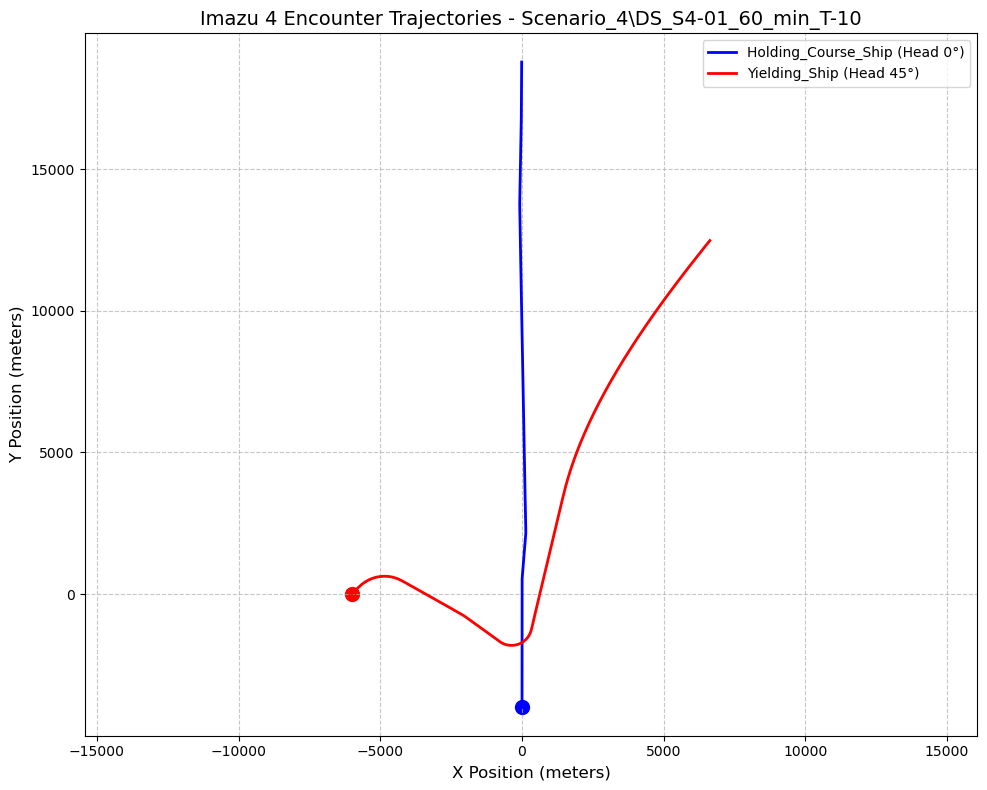

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-02_60_min_T-10_trajectory.png


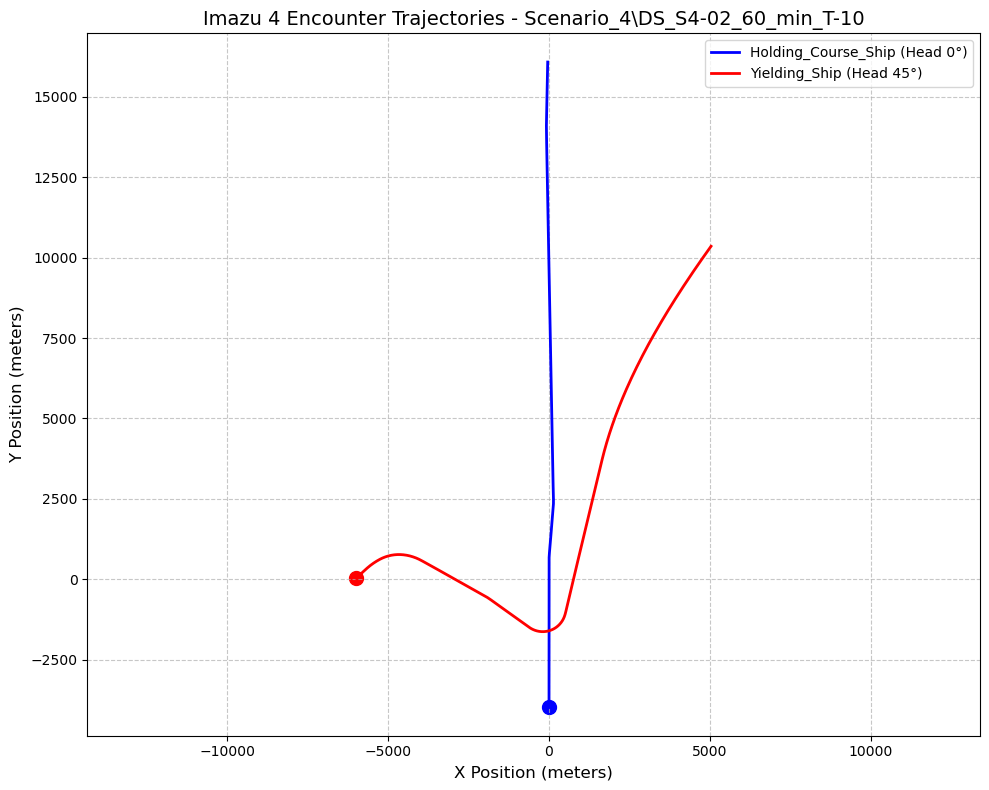

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-03_60_min_T-10_No_Yielding_trajectory.png


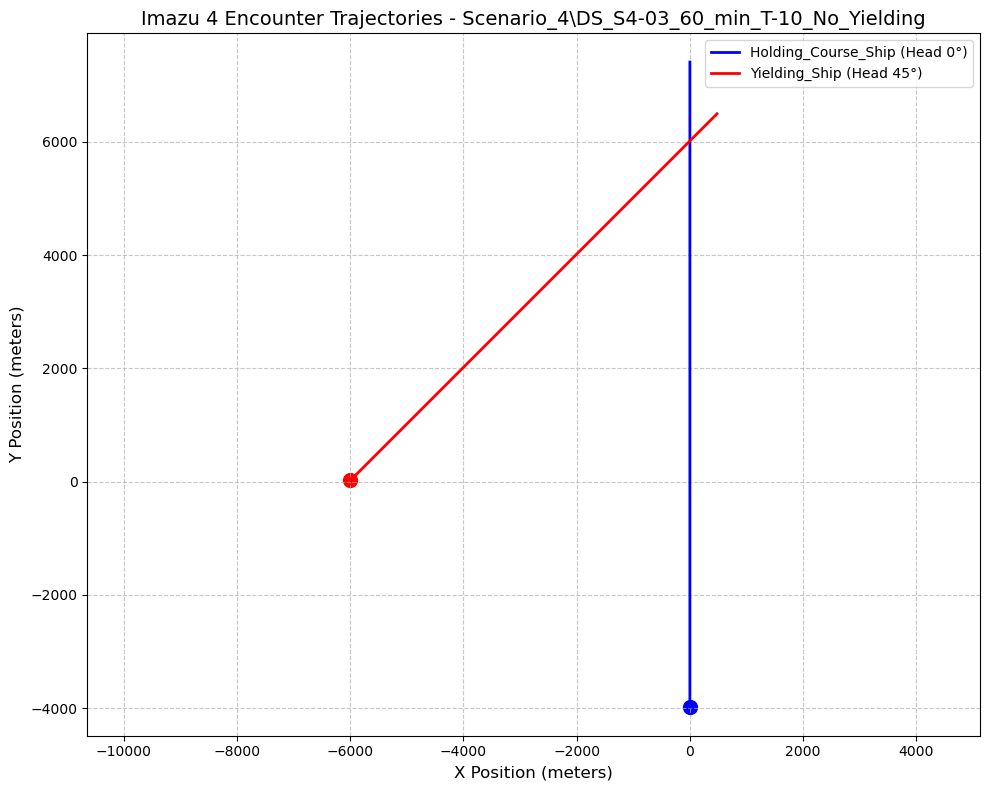

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-04_60_min_T-10_No_Yielding_trajectory.png


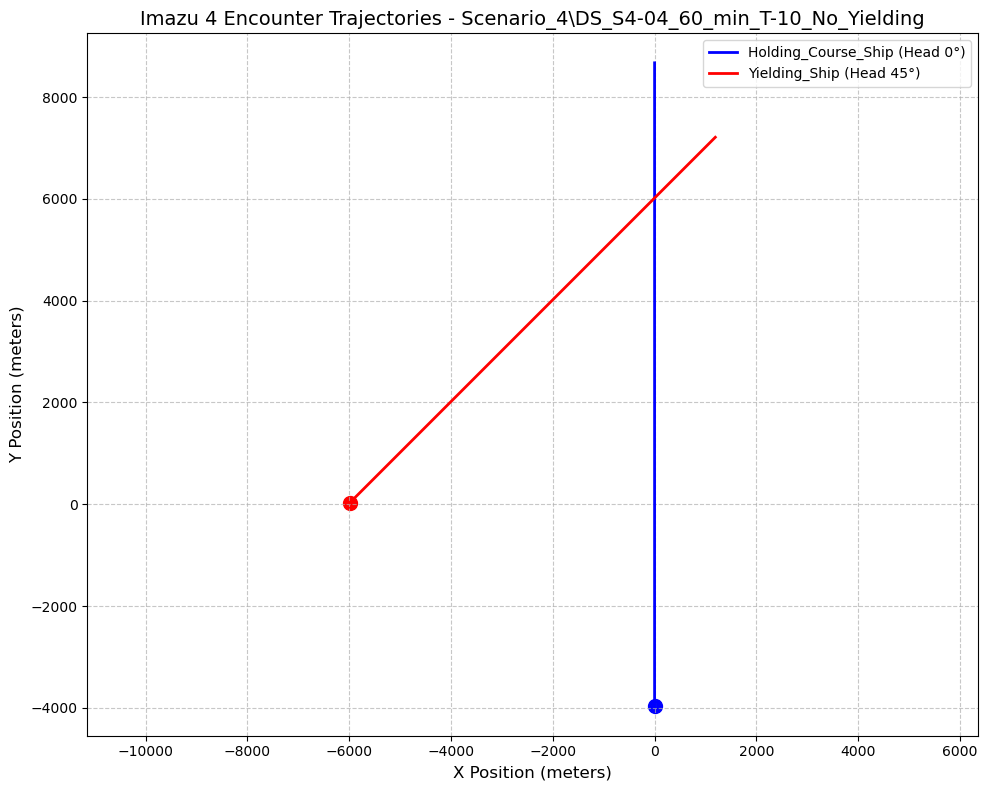

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-05_45_min_T-10_trajectory.png


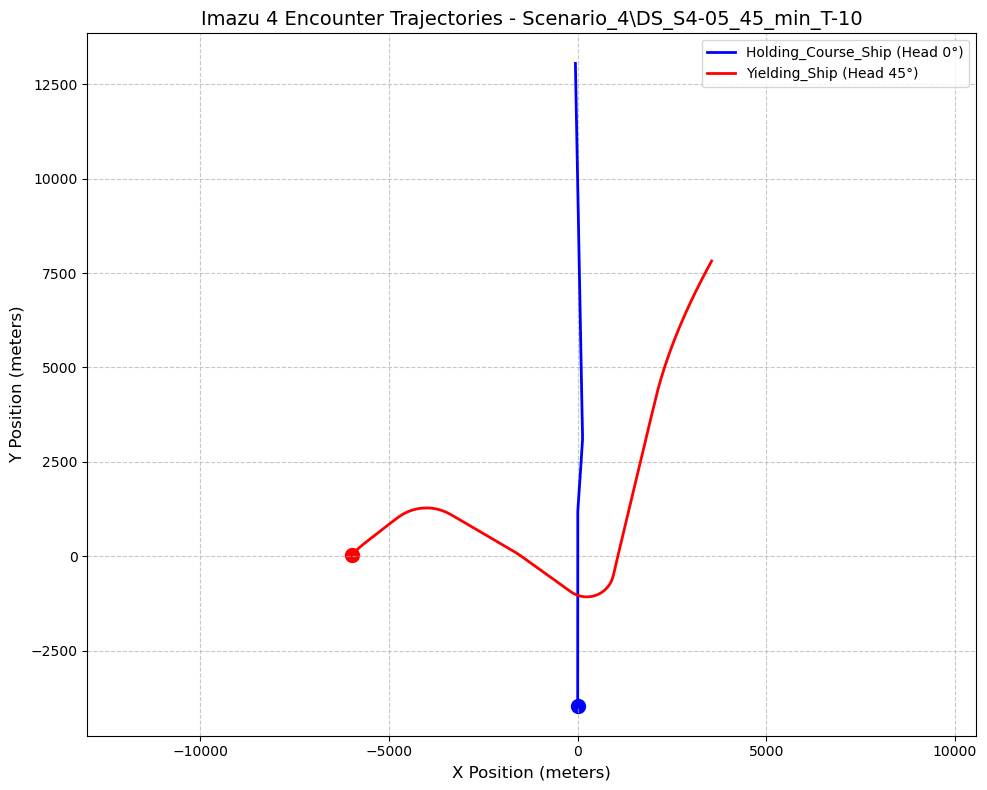

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-06_45_min_T-10_trajectory.png


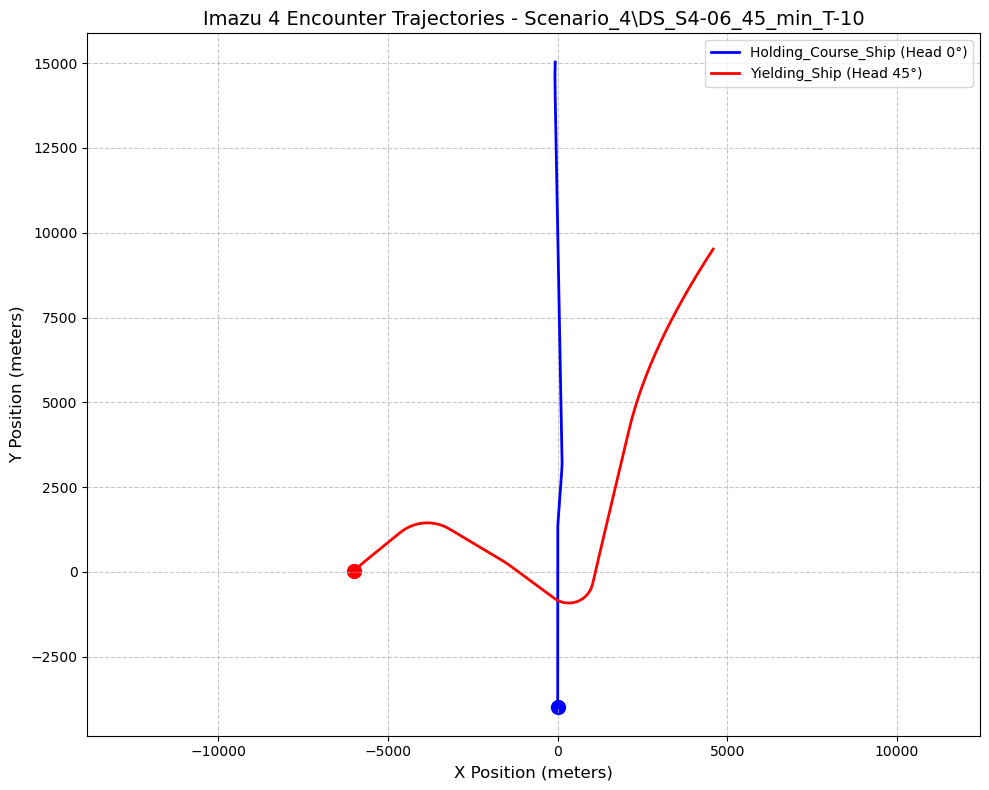

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-07_45_min_T-10_trajectory.png


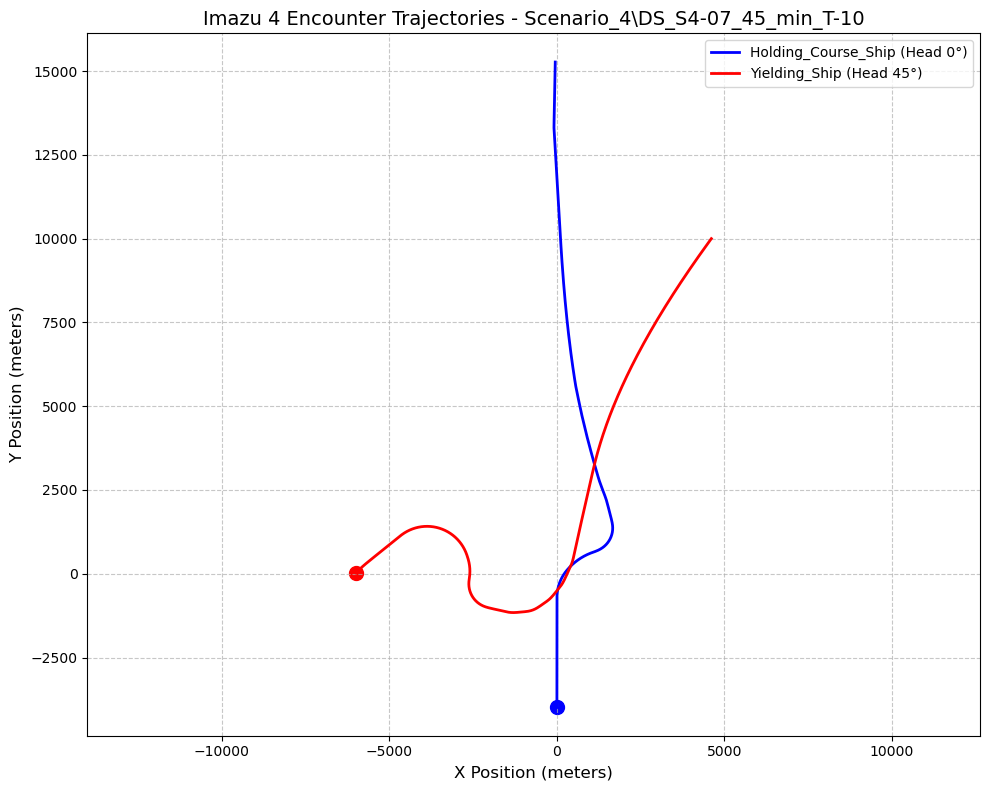

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-08_45_min_T-10_No_Yielding_trajectory.png


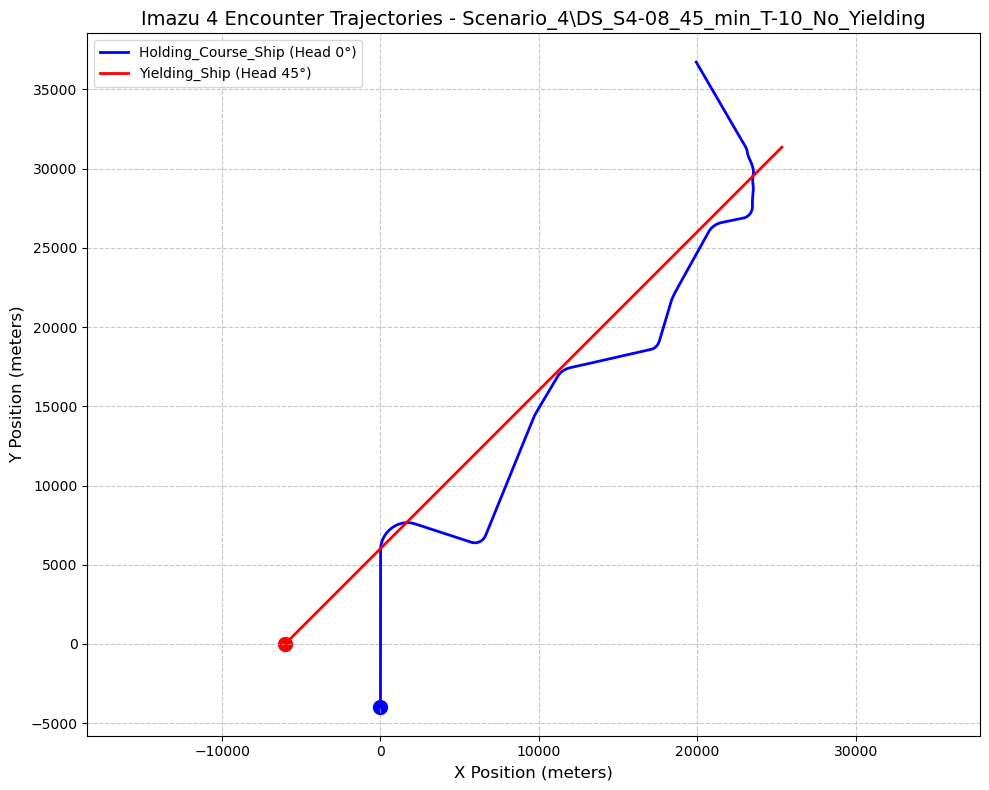

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-09_45_min_T-10_trajectory.png


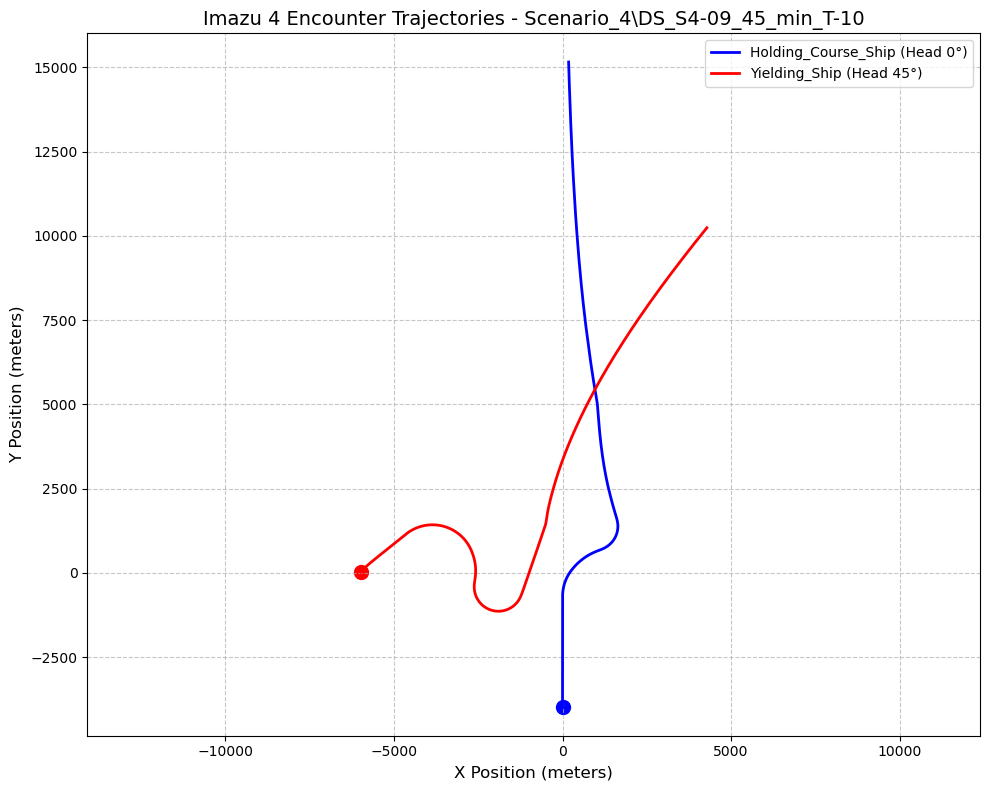

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-10_45_min_T-10_trajectory.png


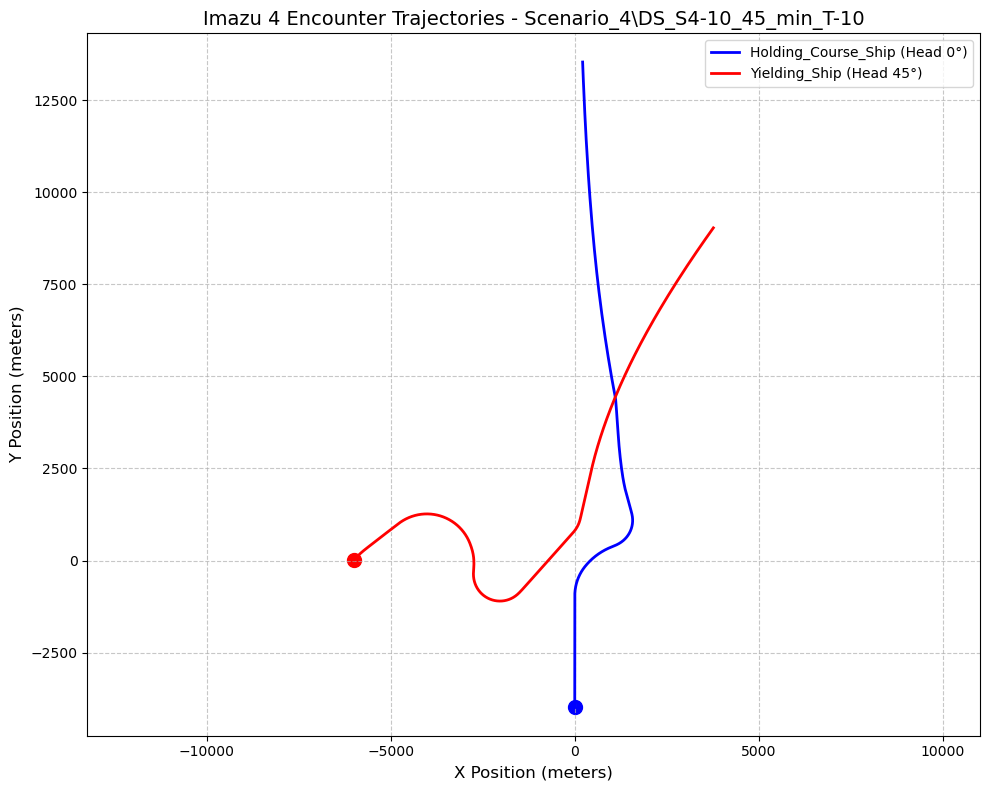

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-11_60_min_T-10_No_Yielding_trajectory.png


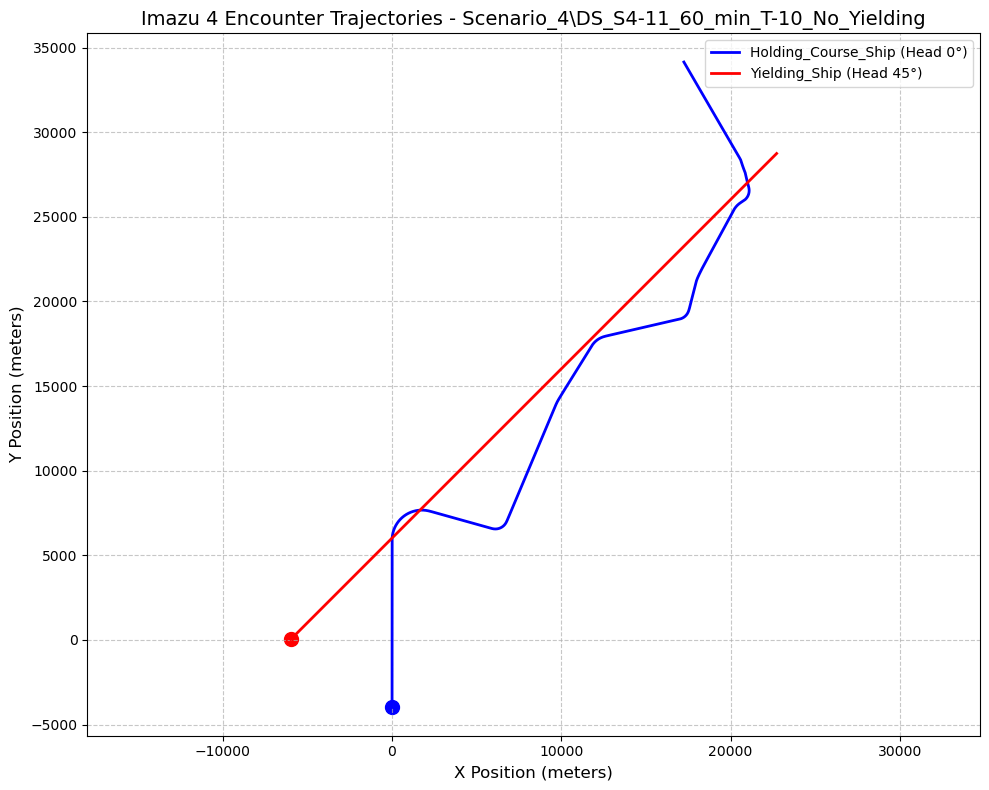

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-12_60_min_T-50_S-1000_trajectory.png


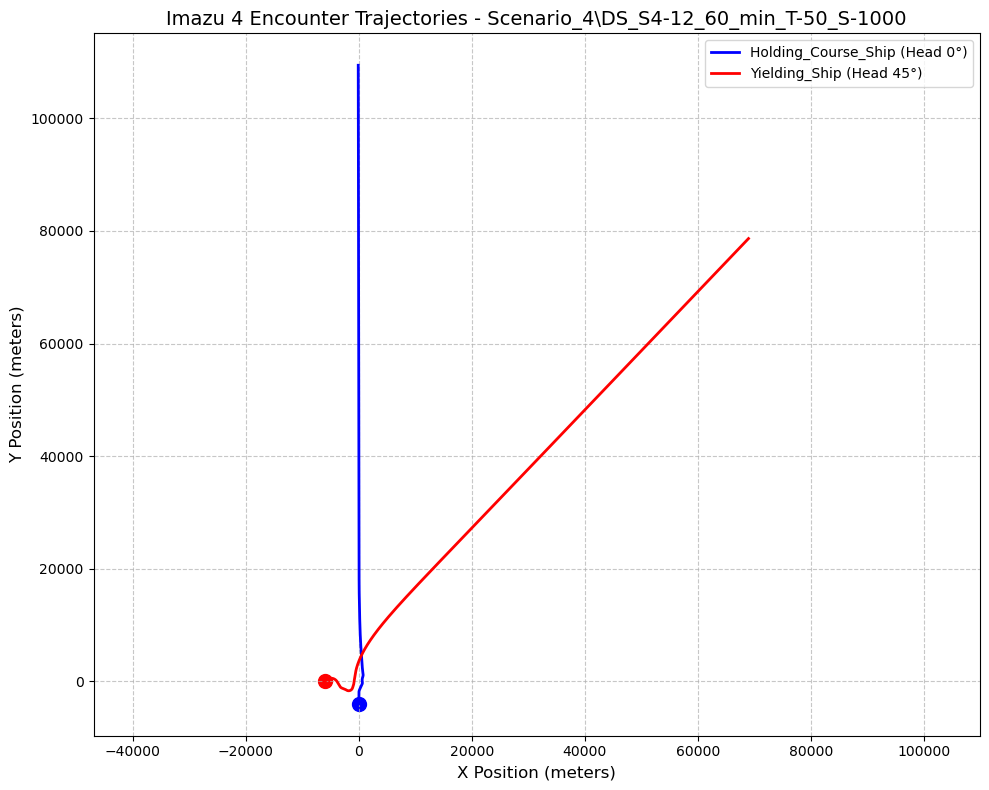

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-13_60_min_T-50_S-1024_No_Yielding_trajectory.png


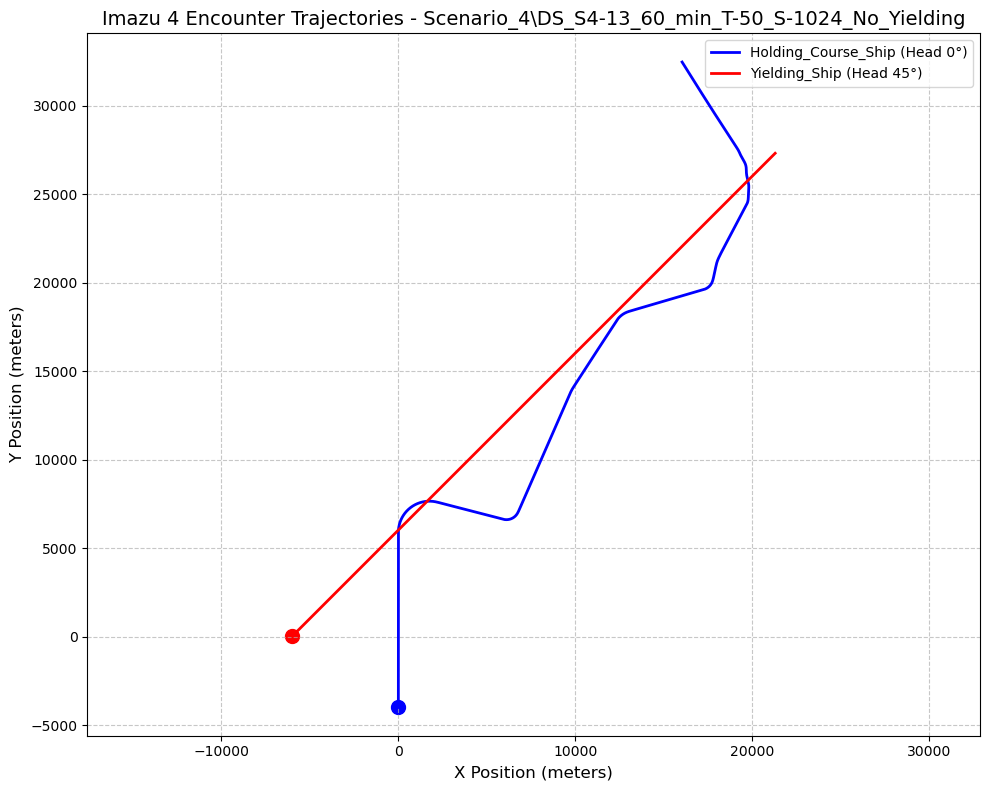

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-14_60_min_T-70_S-1024_trajectory.png


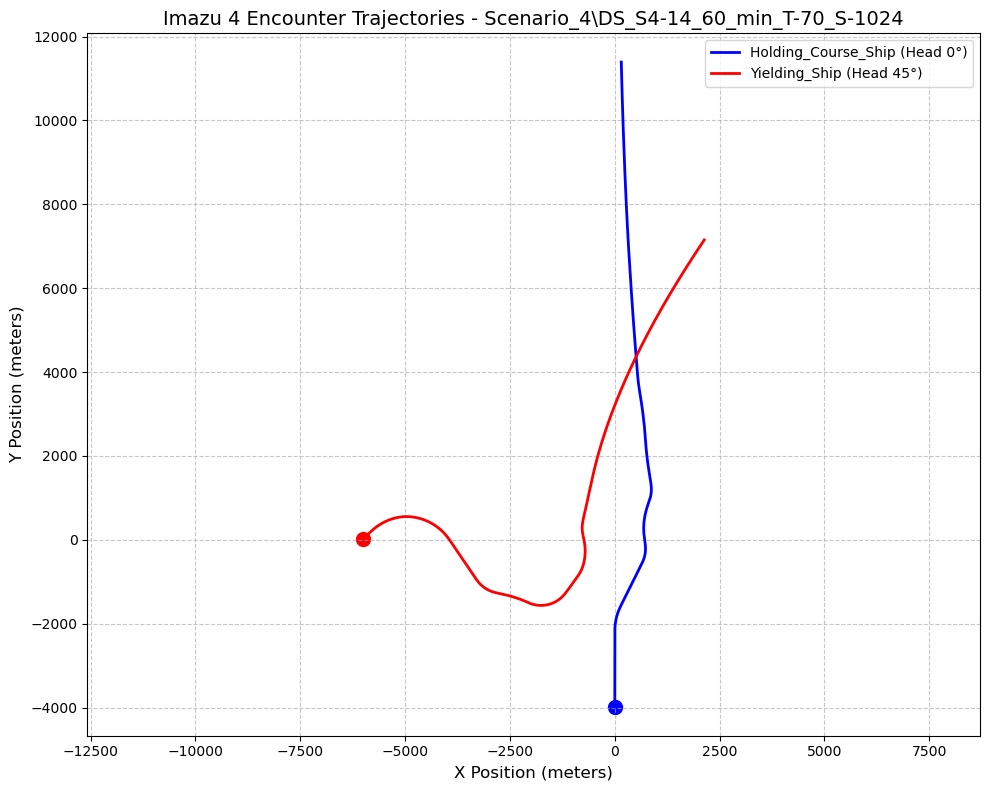

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-15_60_min_T-70_S-1024_No_Yielding_trajectory.png


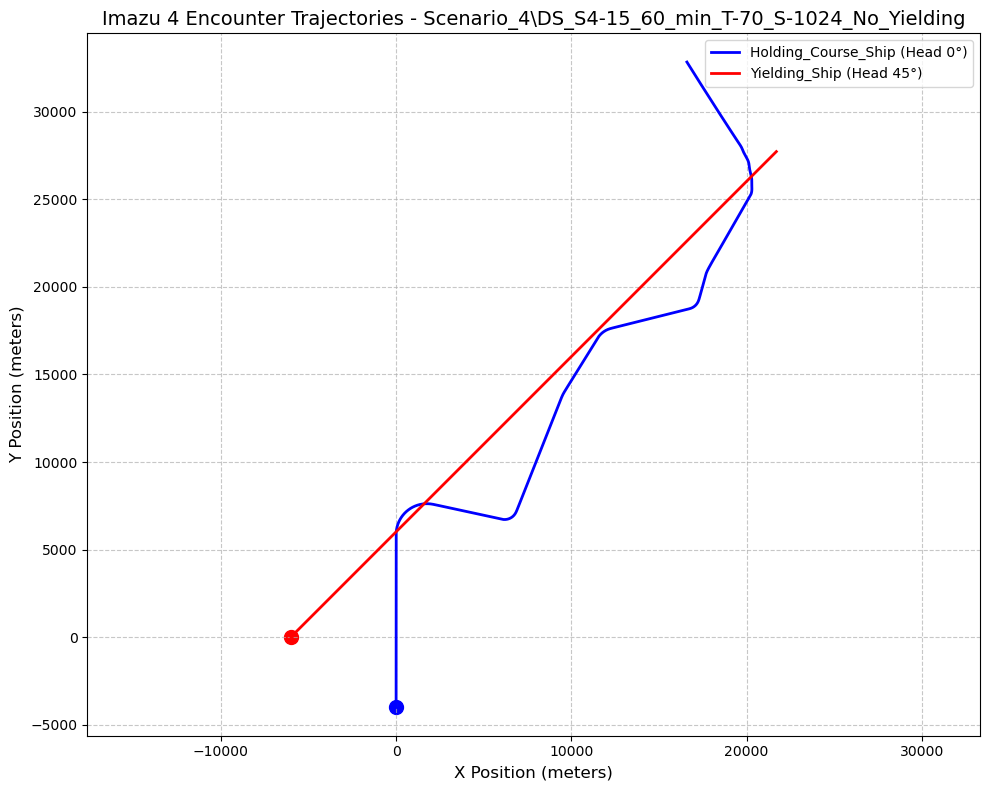

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-16_60_min_T-70_S-1000_ No_Yielding_trajectory.png


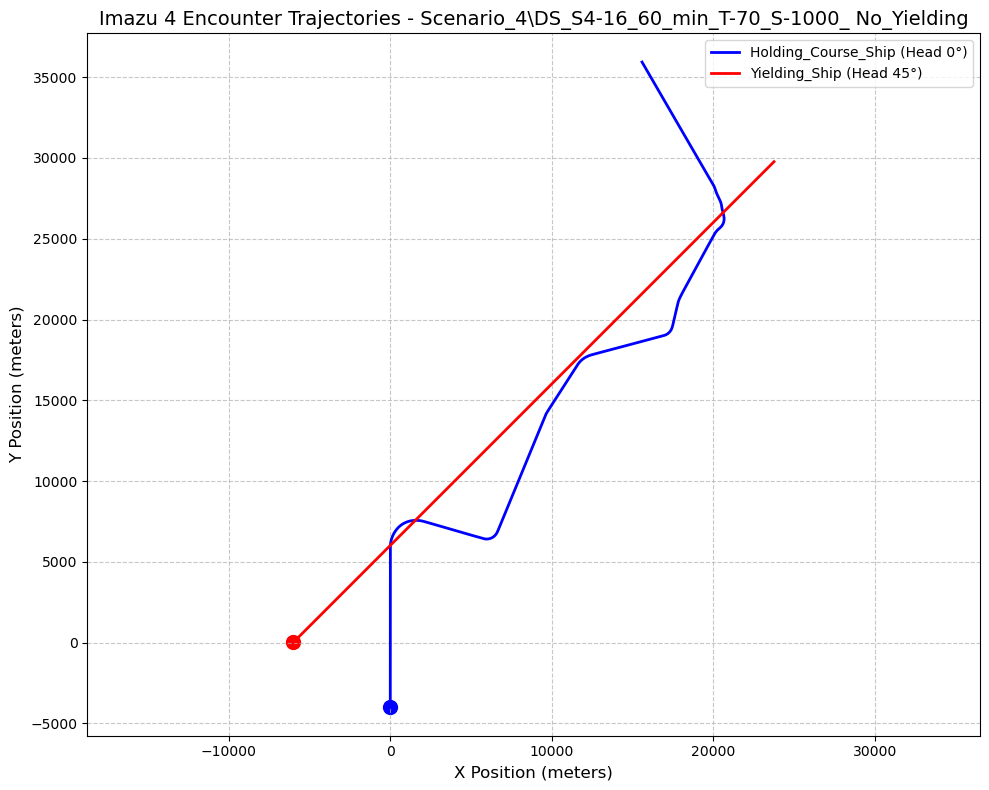

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-17_60_min_T-90_S-4096_No_Yielding_trajectory.png


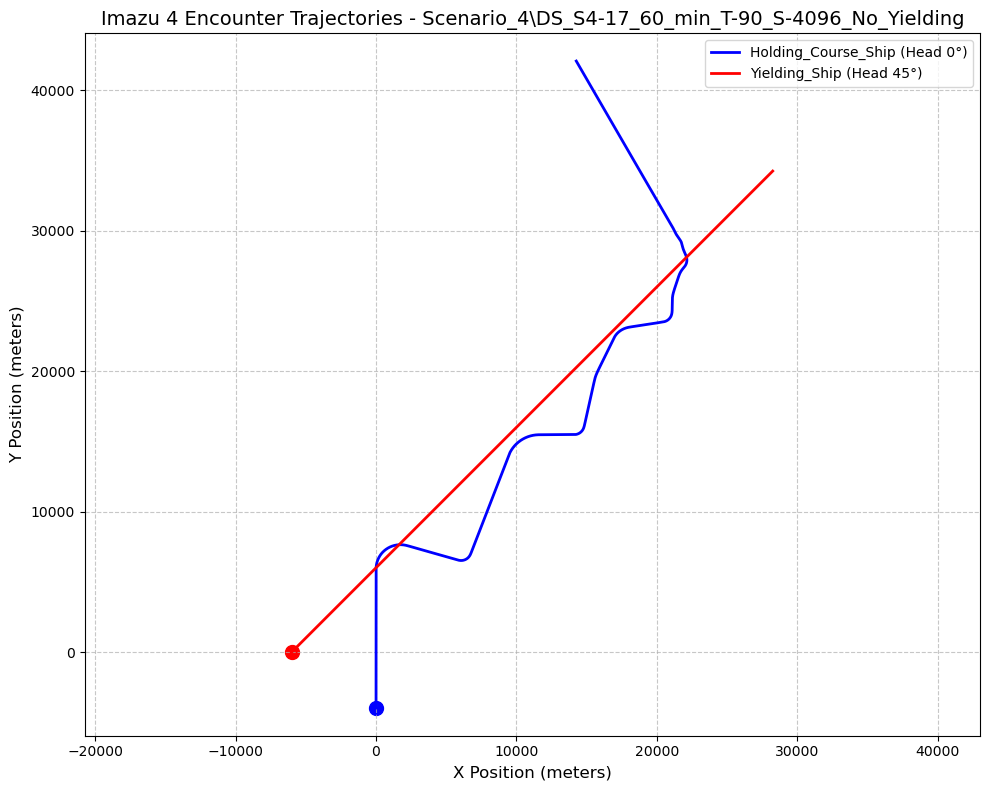

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-18_60_min_T-90_S-0512_trajectory.png


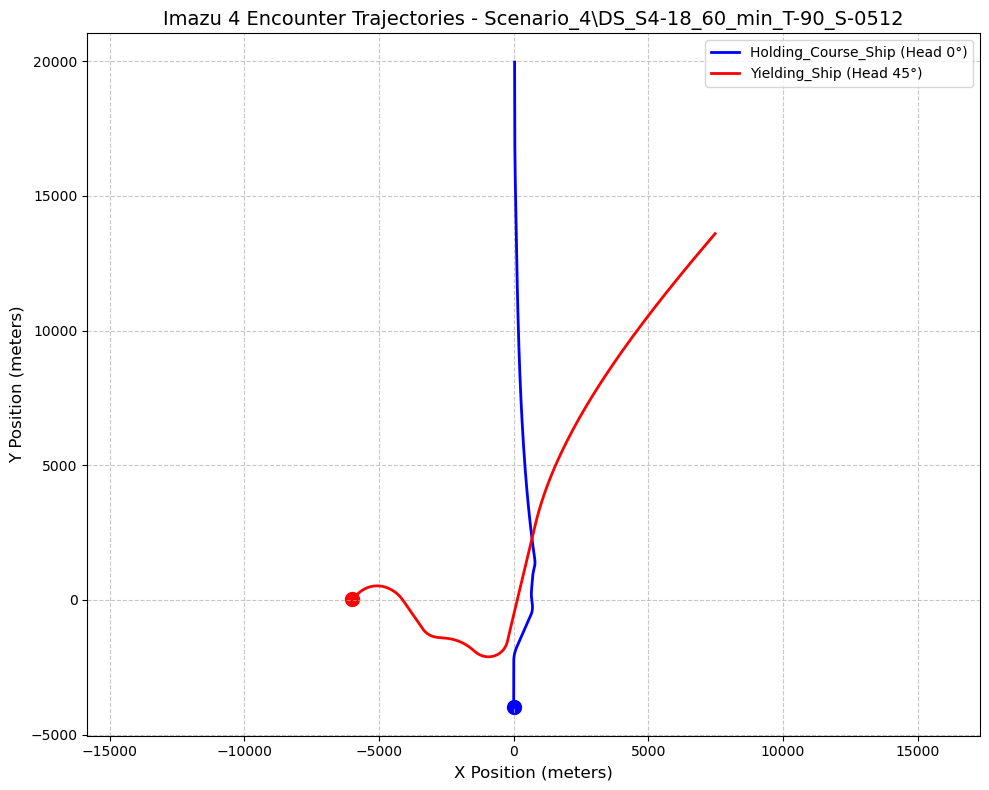

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-19_60_min_T-50_S-0256_trajectory.png


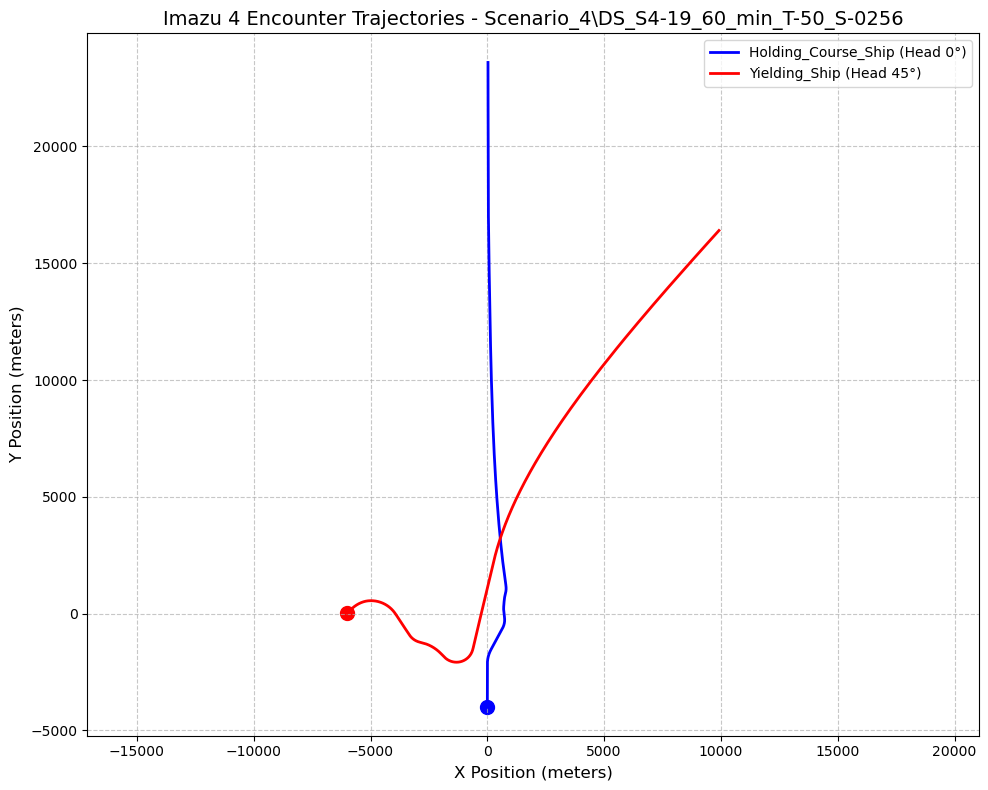

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-20_60_min_T-10_S-1024_No_COLREG_trajectory.png


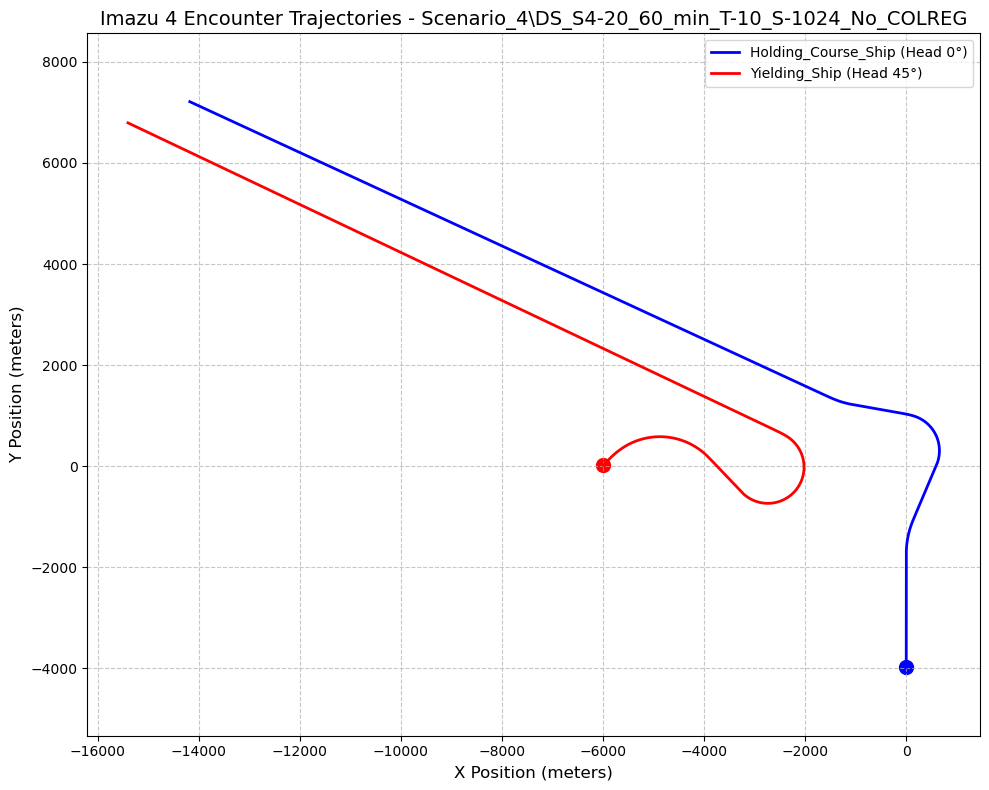

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-21_60_min_T-50_S-2048_No_COLREG_trajectory.png


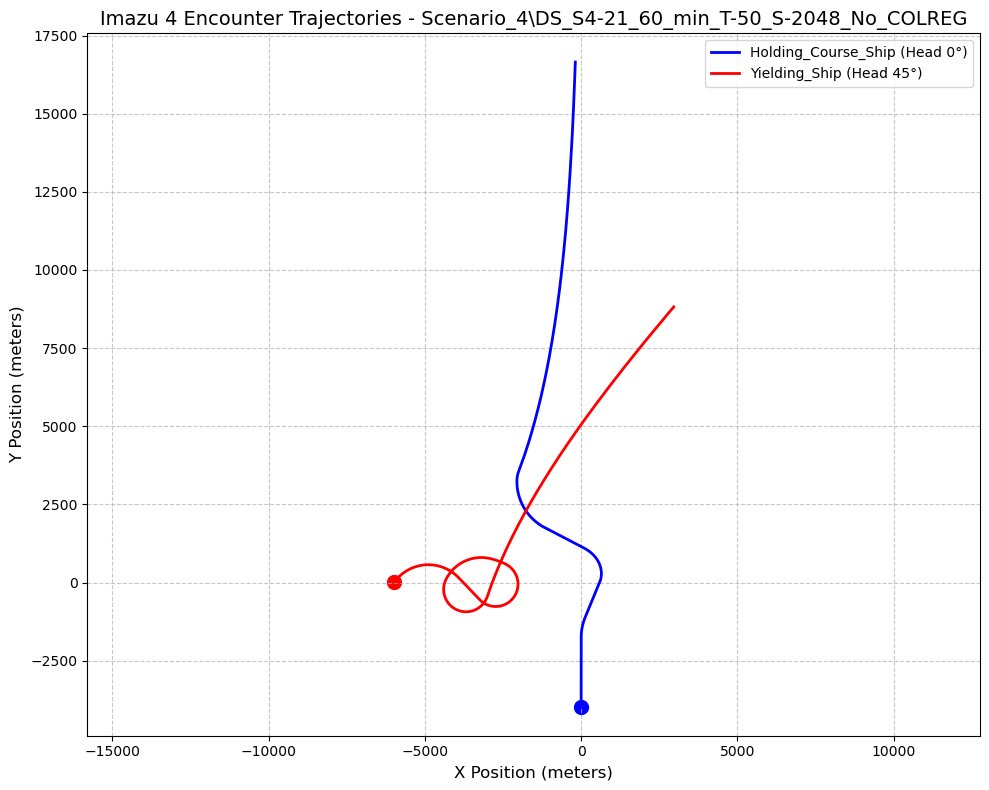

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-21_60_min_T-90_S-0512_No_COLREG_trajectory.png


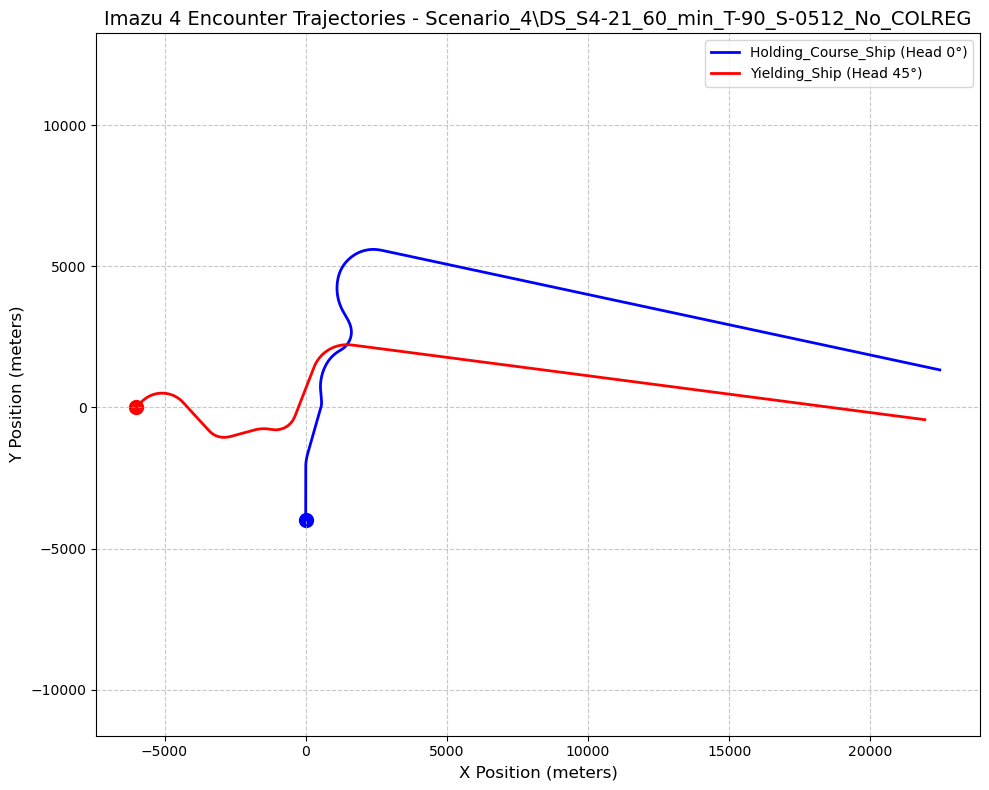

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-22_60_min_T-90_S-2048_No_COLREG_trajectory.png


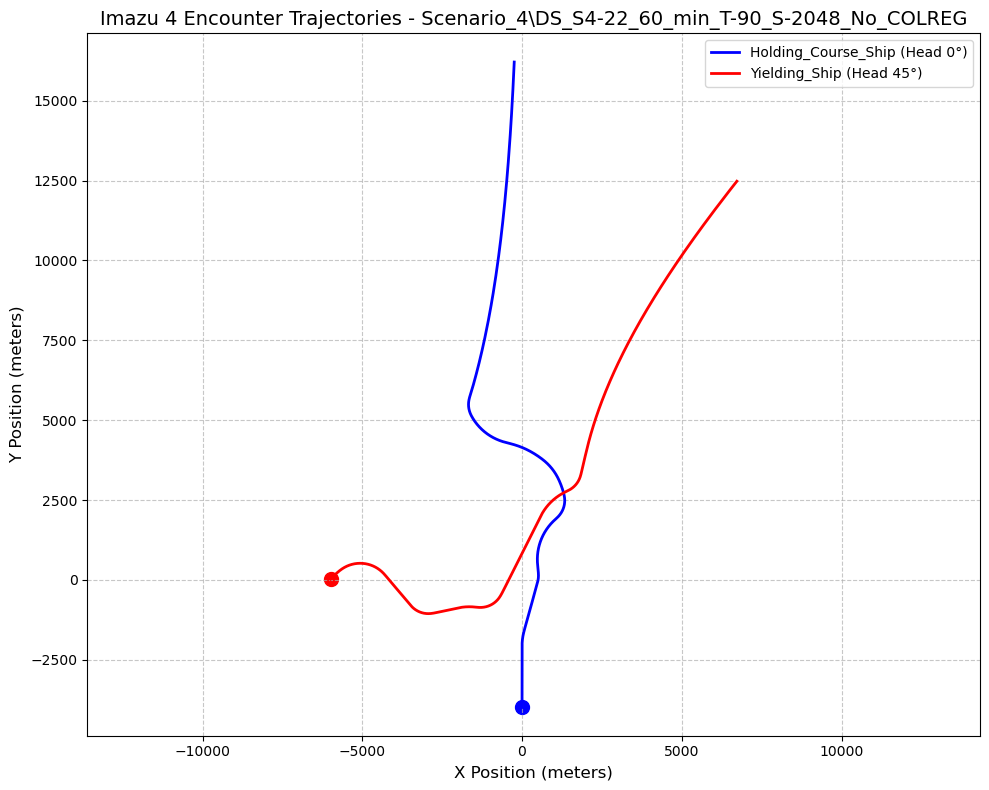

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-23_60_min_T-90_S-1024_No_COLREG_trajectory.png


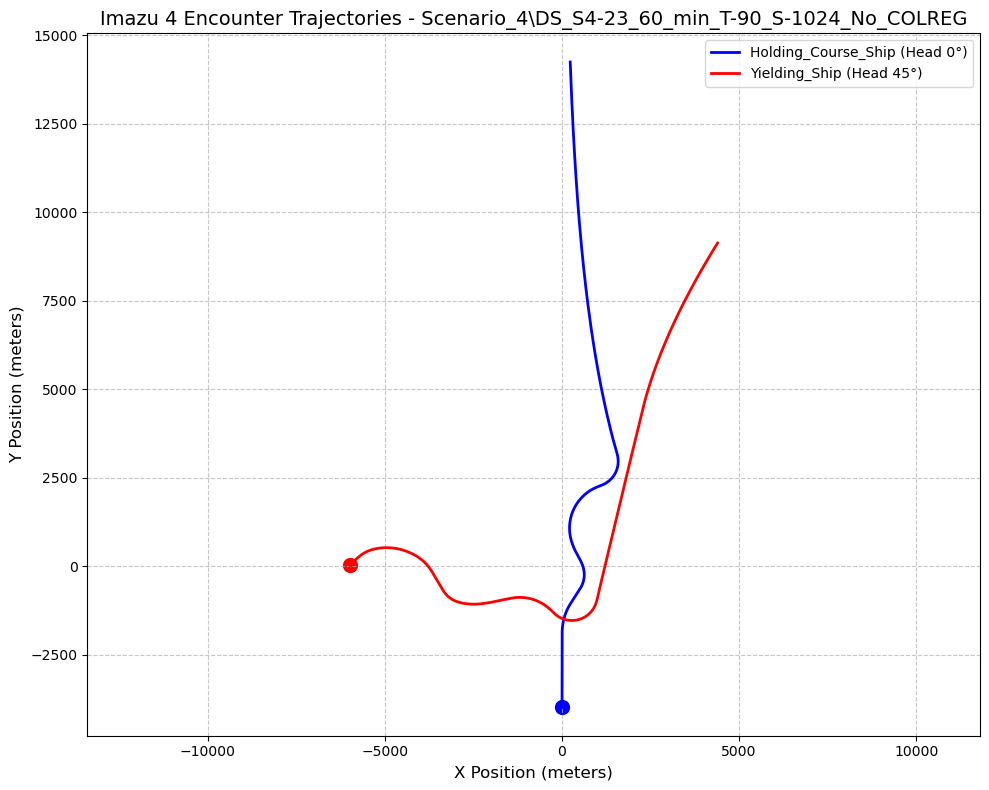

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_DS_S4-24_60_min_T-90_S-1024_No_COLREG_No_Yielding_trajectory.png


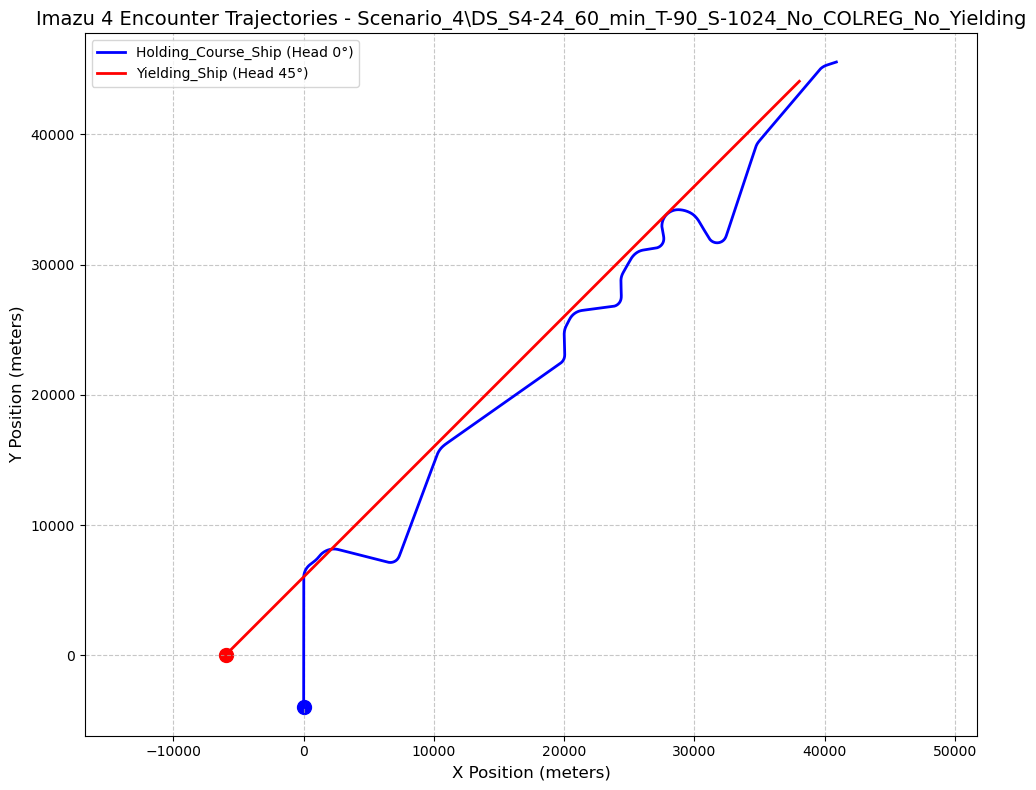

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_GM_S4-01_60_min_T-10_trajectory.png


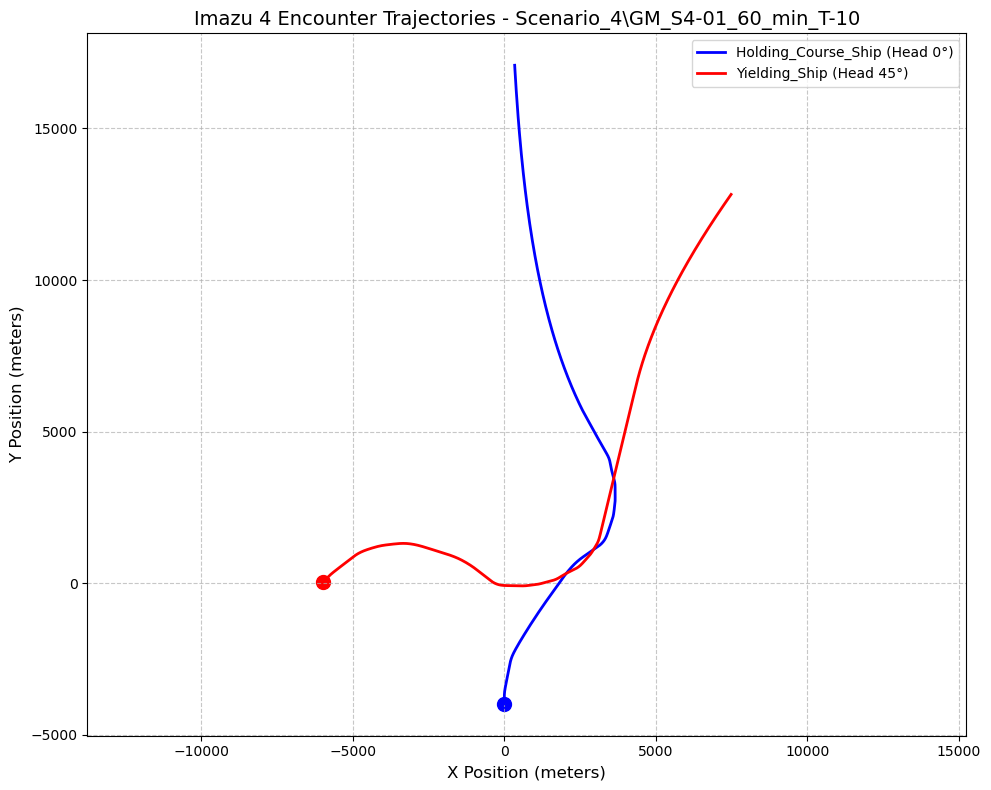

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_GM_S4-02_60_min_T-10_trajectory.png


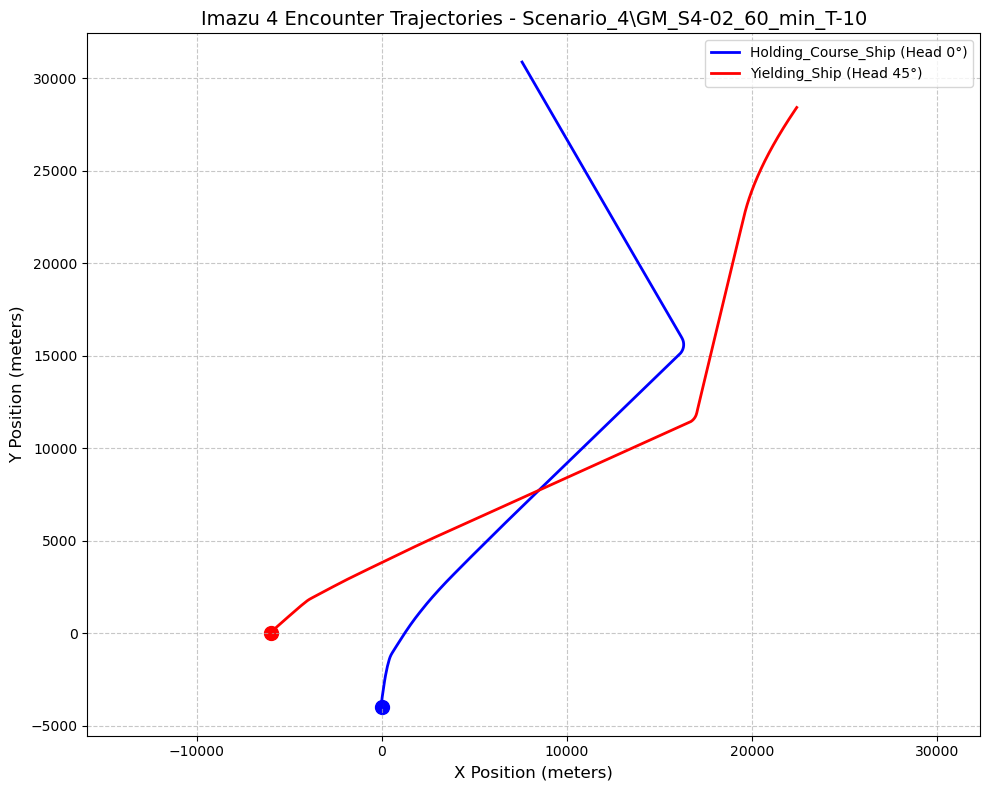

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_GM_S4-03_60_min_T-10_No_Yielding_trajectory.png


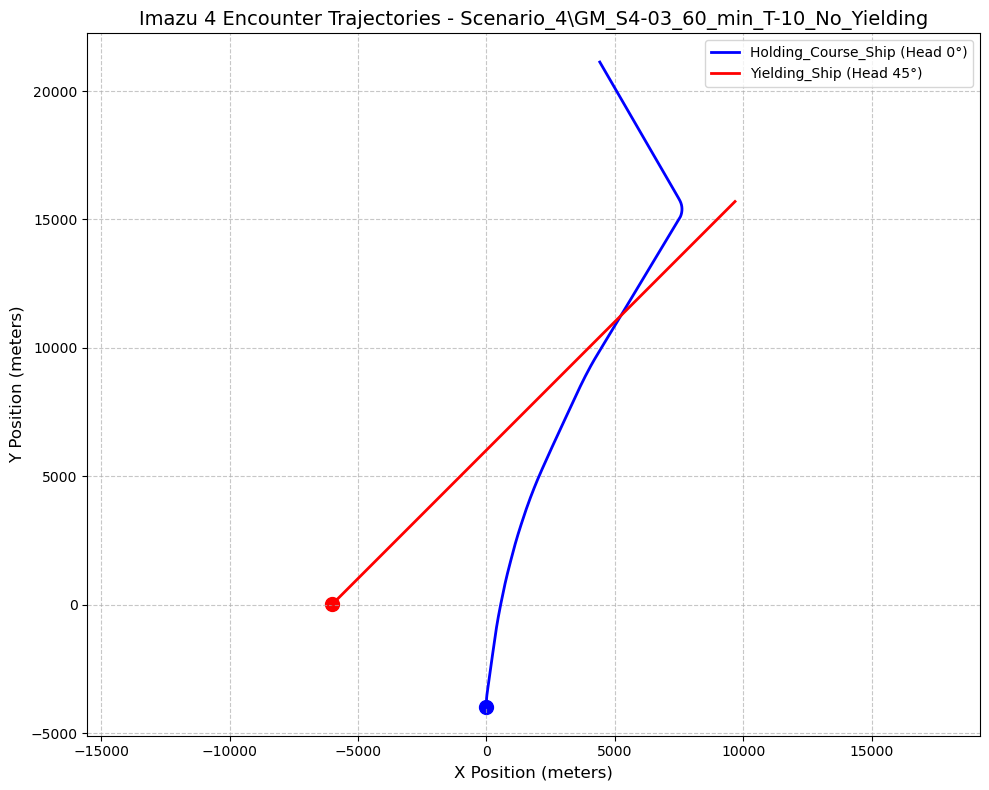

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_GM_S4-04_60_min_T-10_No_Yielding_trajectory.png


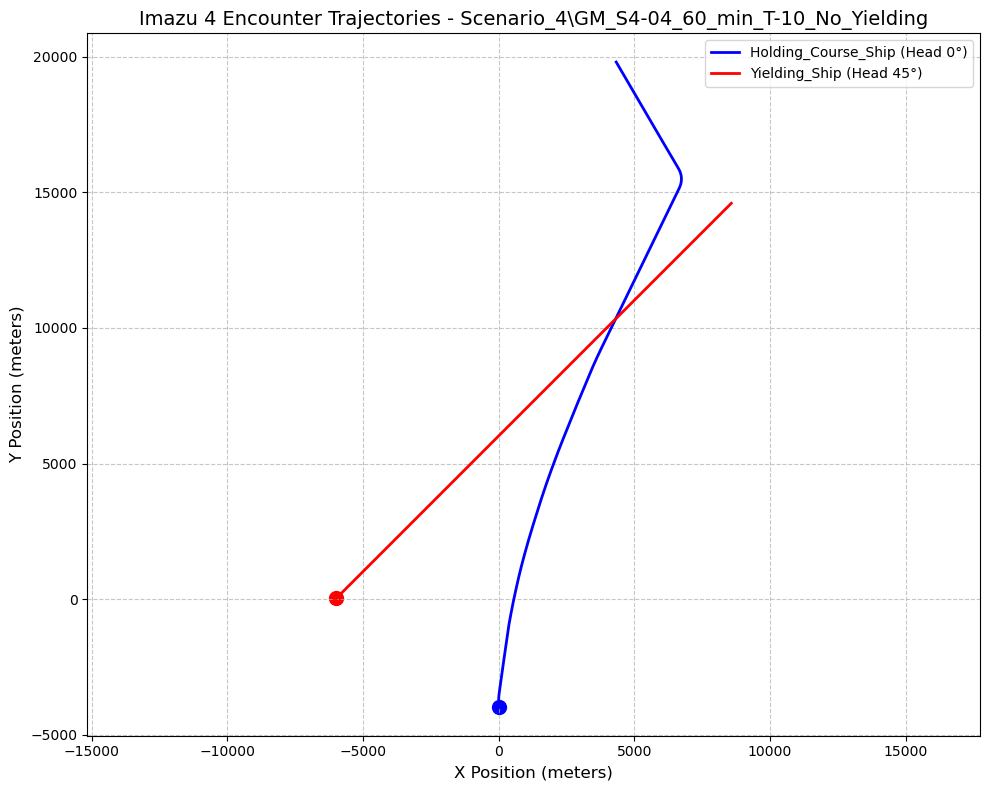

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_GM_S4-05_45_min_T-10_trajectory.png


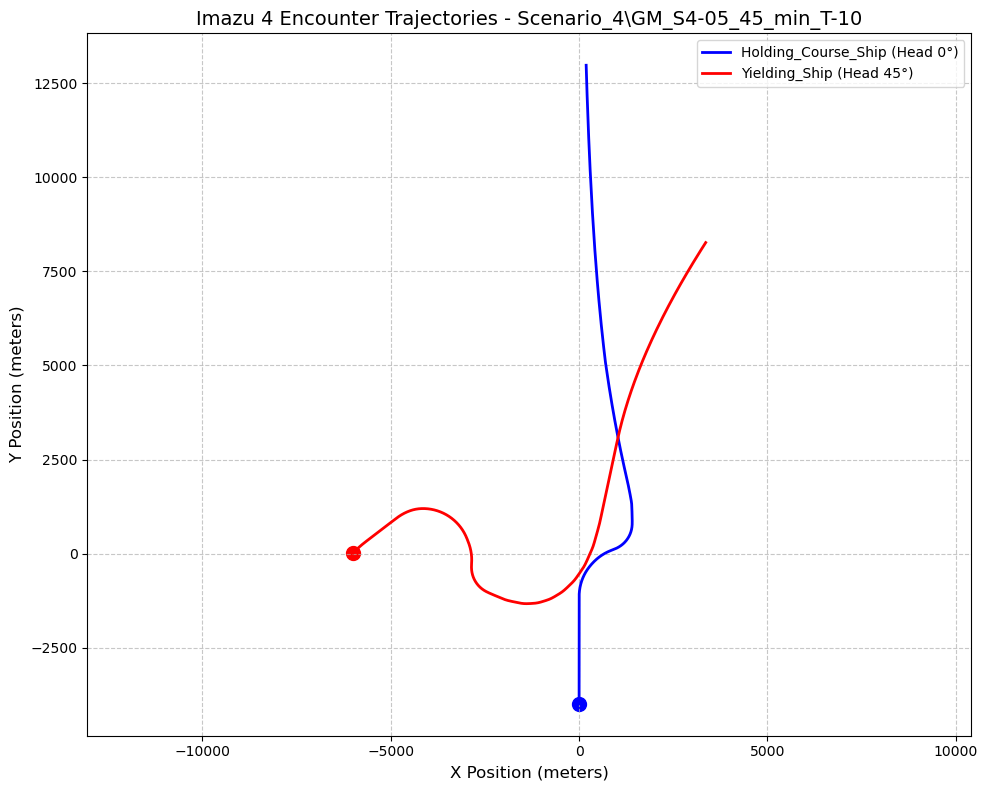

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_GM_S4-06_45_min_T-50_No_Yielding_trajectory.png


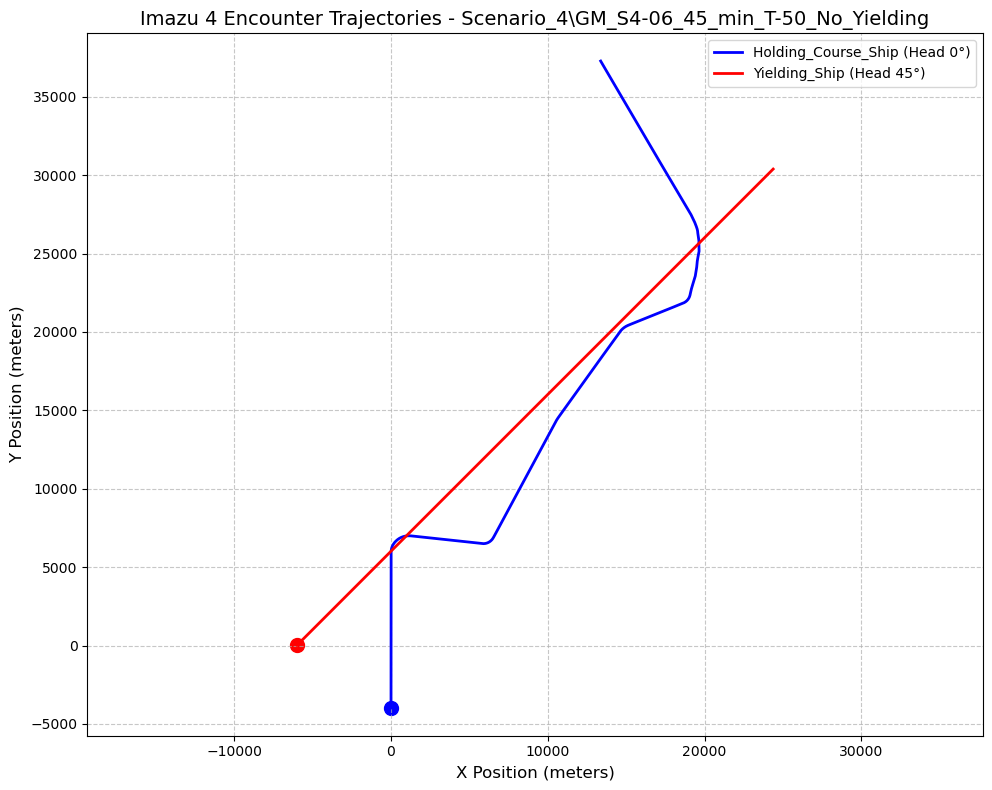

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_GM_S4-07_45_min_T-50_No_Yielding_trajectory.png


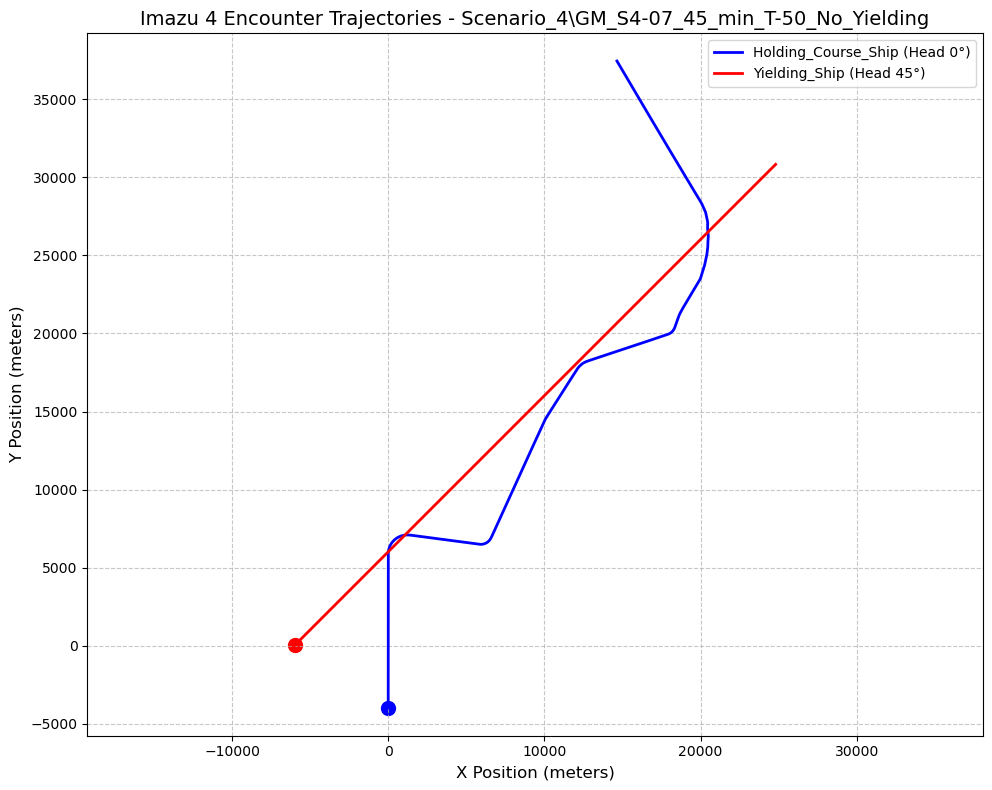

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_GM_S4-08_60_min_T-70_S-1000_trajectory.png


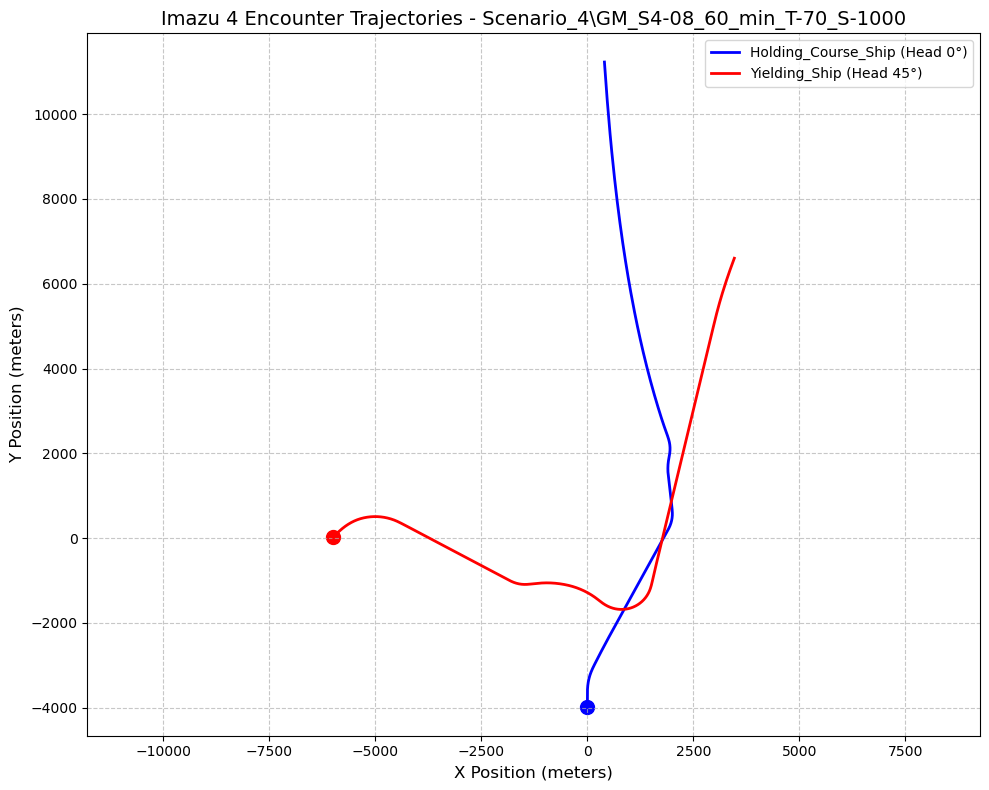

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_GM_S4-09_60_min_T-70_S-0999_No_Yielding_trajectory.png


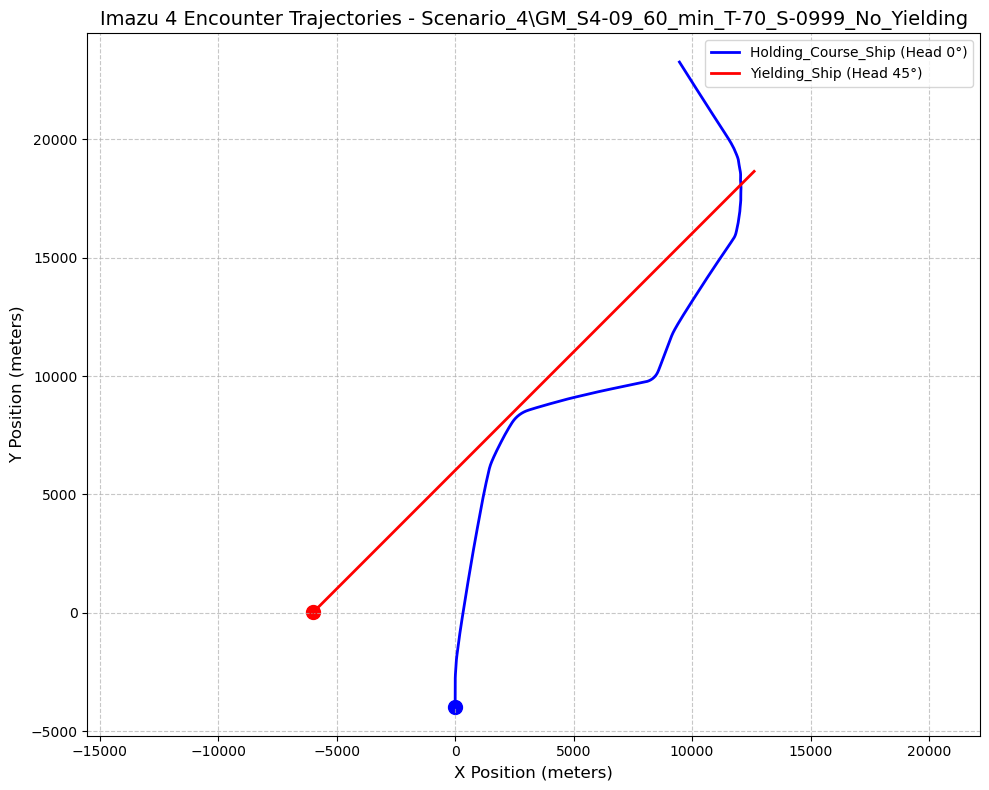

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Saved plot as: Scenario_4_GM_S4-10_60_min_T-70_S-2048_No_Yielding_trajectory.png


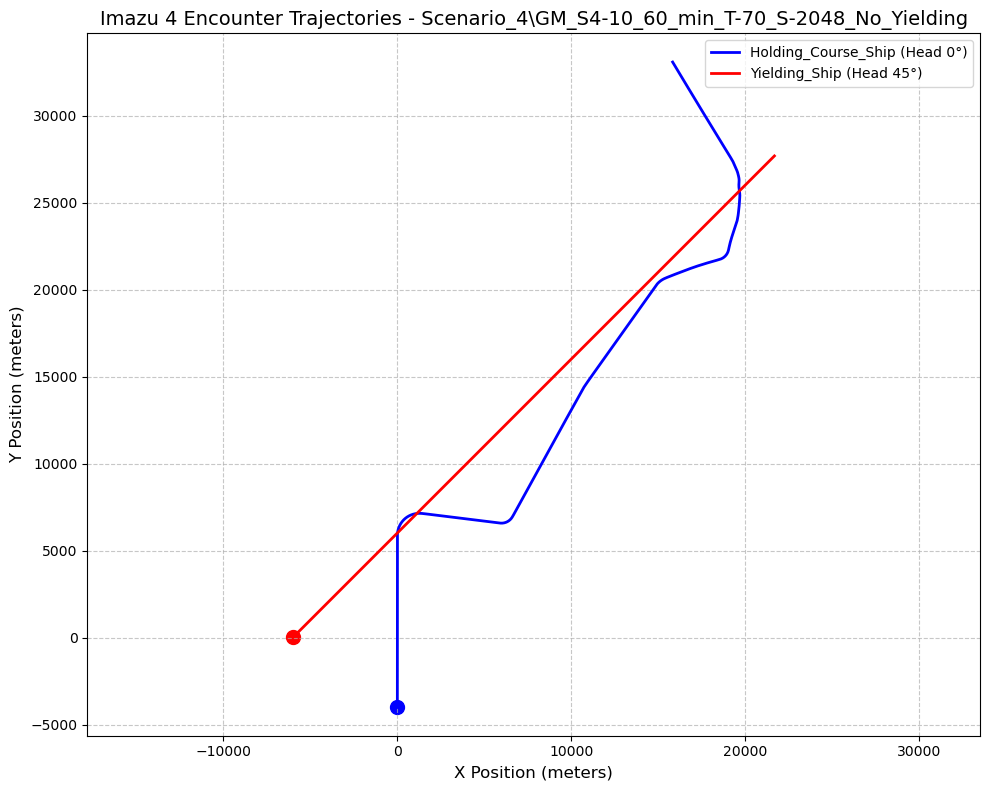

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
All plots generated successfully!
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [13]:
def plot_trajectories(df, sim_name):
    ### Plots the 2D spatial trajectories of all ships in the dataframe.
    
    ### first we do this: check if the dataframe is empty just in case
    if df.empty:
        print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
        print(f"No data available to plot for {sim_name}.")
        print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
        return
        
    plt.figure(figsize=(10, 8))
    
    ### next we find all unique ship names by looking at the column headers
    ship_names = [col.replace('x_m_', '') for col in df.columns if col.startswith('x_m_')]
    
    ### then we define a list of colors to cycle through for different ships
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta']
    
    ### next we loop through each ship to plot its path and starting position
    for idx, ship in enumerate(ship_names):
        color = colors[idx % len(colors)] # select a color based on the index
        
        x_col = f'x_m_{ship}'
        y_col = f'y_m_{ship}'
        
        ### we try to get the initial heading to include it in the label
        course_col = f'course_deg_{ship}'
        label = f'{ship}'
        if course_col in df.columns:
            initial_heading = df[course_col].iloc[0]
            label += f' (Head {initial_heading:.0f}°)'
            
        ### plot the path
        plt.plot(df[x_col], df[y_col], label=label, color=color, linewidth=2)
        
        ### mark the starting position with a dot
        plt.scatter(df[x_col].iloc[0], df[y_col].iloc[0], color=color, marker='o', s=100)
        
    ### formatting the chart
    plt.title(f"Imazu 4 Encounter Trajectories - {sim_name}", fontsize=14)
    plt.xlabel("X Position (meters)", fontsize=12)
    plt.ylabel("Y Position (meters)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    ### crucial: this ensures 1 meter in X looks exactly as long as 1 meter in Y
    plt.axis('equal') 
    
    plt.tight_layout()
    
    ### finally we save the plot to a file before showing it
    ### we replace backslashes and slashes to avoid creating accidental folders
    safe_name = sim_name.replace('\\', '_').replace('/', '_')
    file_name = f"{safe_name}_trajectory.png"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    print(f"Saved plot as: {file_name}")
    
    plt.show()

print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
print("Generating trajectory plots for all simulations...")
print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

### we loop through all the items in our dictionary
for sim_name, df in simulations.items():
    ### generate a plot for each simulation folder
    plot_trajectories(df, sim_name)

print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
print("All plots generated successfully!")
print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

# Vessel Collision Risk Analysis (Simulation Time at Risk)

**Overview**
This script calculates a dynamic, multi-factor collision risk index between a holding-course vessel and a yielding vessel throughout a simulation. It then evaluates this risk index against predefined thresholds to identify the specific time windows where the encounter becomes critical.

---

**I. Kinematic and Relative Motion Calculations**
The `calculate_collision_risk` function first establishes the relative motion between the two vessels to find the Closest Point of Approach (CPA) metrics.

* **Velocity Components:** The script converts each ship's course from degrees to radians ($\theta$) and calculates the $X$ and $Y$ velocity components using their speed ($v$):

$$v_{x} = v \cdot \sin(\theta)$$


$$v_{y} = v \cdot \cos(\theta)$$


* **Relative Motion:** It computes the relative position ($\Delta x, \Delta y$) and relative velocity ($\Delta v_x, \Delta v_y$) between the yielding ship and the holding ship.
* **Time to Closest Point of Approach (TCPA):** This determines how many seconds remain until the ships reach their minimum distance. If the ships are already moving apart, TCPA is floored to $0$.

$$TCPA = -\frac{\Delta x \cdot \Delta v_x + \Delta y \cdot \Delta v_y}{\Delta v_x^2 + \Delta v_y^2}$$


* **Distance to Closest Point of Approach (DCPA):** Using the current Euclidean distance ($d$) and the TCPA, the script predicts the minimum physical distance the ships will reach:

$$DCPA = \sqrt{\max(0, d^2 - (TCPA^2 \cdot (\Delta v_x^2 + \Delta v_y^2)))}$$



---

**II. Risk Index Formulation**
Once the kinematic variables are established, the script translates them into a normalized risk score bounded between $0.0$ (no risk) and $1.0$ (maximum risk). It uses a linear decay formula for three separate factors, clipping the values so they do not fall outside the $0$ to $1$ range:

* **DCPA Risk:** Assesses spatial danger. Maximum risk is reached at $0$ meters, decaying to zero risk at $1000$ meters.

$$Risk_{DCPA} = \max\left(0, \min\left(1, \frac{1000 - DCPA}{1000}\right)\right)$$


* **TCPA Risk:** Assesses temporal danger. Maximum risk is reached at $0$ seconds, decaying to zero risk at $600$ seconds.

$$Risk_{TCPA} = \max\left(0, \min\left(1, \frac{600 - TCPA}{600}\right)\right)$$


* **Current Distance Risk:** Assesses immediate proximity danger. Maximum risk is reached at $0$ meters, decaying to zero risk at $5000$ meters.

$$Risk_{Dist} = \max\left(0, \min\left(1, \frac{5000 - d}{5000}\right)\right)$$


* **Total Risk Index:** The final risk value assigned to the time step is the unweighted average of the three components:

$$Risk_{Total} = \frac{Risk_{DCPA} + Risk_{TCPA} + Risk_{Dist}}{3}$$



---

**III. Threshold Evaluation and Reporting**
The `get_risk_threshold_times` function processes the calculated risk data to extract actionable insights.

* **Data Iteration:** It systematically processes every merged simulation dataframe stored in the `sim_data` dictionary.
* **Threshold Scanning:** It scans the calculated `risk` column against four distinct severity thresholds: **0.25**, **0.50**, **0.75**, and **0.90**.
* **Time Extraction:** When the risk exceeds a specific threshold, it extracts the corresponding timestamps (`time_s`).
* **Duration Reporting:** It outputs the exact starting second, the ending second, and calculates the total duration of the critical risk period. If the threshold is never breached, it explicitly states that no instances were found.

In [14]:
def calculate_collision_risk(df):
    ### first we do this: extract positions, speeds, and courses (converted to radians) for both ships
    x1 = df['x_m_Holding_Course_Ship']
    y1 = df['y_m_Holding_Course_Ship']
    v1 = df['speed_ms_Holding_Course_Ship']
    c1 = np.radians(df['course_deg_Holding_Course_Ship'])
    
    x2 = df['x_m_Yielding_Ship']
    y2 = df['y_m_Yielding_Ship']
    v2 = df['speed_ms_Yielding_Ship']
    c2 = np.radians(df['course_deg_Yielding_Ship'])
    
    ### next we calculate the specific X and Y velocity components using trigonometry
    v1x = v1 * np.sin(c1)
    v1y = v1 * np.cos(c1)
    v2x = v2 * np.sin(c2)
    v2y = v2 * np.cos(c2)
    
    ### then we compute relative position and relative velocity
    dx = x2 - x1
    dy = y2 - y1
    dvx = v2x - v1x
    dvy = v2y - v1y
    
    ### we calculate the relative speed squared to use as a denominator in TCPA
    v_rel_sq = dvx**2 + dvy**2
    
    ### next we calculate TCPA ensuring we do not divide by zero
    tcpa = -(dx * dvx + dy * dvy) / np.where(v_rel_sq == 0, 1e-9, v_rel_sq)
    
    ### if TCPA is negative it means the ships are moving apart so we set it to 0
    tcpa = np.where(tcpa < 0, 0, tcpa)
    
    ### then we calculate the current distance between the ships
    distance = np.sqrt(dx**2 + dy**2)
    
    ### we calculate DCPA using the current distance and TCPA
    dcpa = np.sqrt(np.maximum(0, distance**2 - (tcpa**2 * v_rel_sq)))
    
    ### finally we calculate the individual risk components using np.clip to bind between 0 and 1
    dcpa_risk = np.clip((1000 - dcpa) / 1000, 0, 1)
    tcpa_risk = np.clip((600 - tcpa) / 600, 0, 1)
    dist_risk = np.clip((5000 - distance) / 5000, 0, 1)
    
    ### calculate the overall risk index and store it back into the dataframe
    df['risk'] = (dcpa_risk + tcpa_risk + dist_risk) / 3
    df['distance'] = distance # keeping distance in case it is needed elsewhere
    
    return df

def get_risk_threshold_times(sim_data):
    thresholds = [0.25, 0.5, 0.75, 0.9]
    
    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    
    ### first we do this: loop through every simulation stored in our loaded dictionary
    for folder_name, df in sim_data.items():
        print(f"Risk Analysis for: {folder_name}")
        
        ### next we check if the dataframe is empty just in case
        if df.empty:
            print("No data available for this simulation.")
            print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
            continue
            
        ### then we apply our risk calculation to the current merged dataframe
        df = calculate_collision_risk(df)
        
        ### finally we evaluate the risk column against our specified thresholds
        for threshold in thresholds:
            exceed_times = df[df['risk'] > threshold]['time_s'].tolist()
            
            if exceed_times:
                print(f"Risk > {threshold}: from {exceed_times[0]}s to {exceed_times[-1]}s - total {exceed_times[-1] - exceed_times[0]}s")
            else:
                print(f"Risk > {threshold}: No instances found")
                
        ### print a separator between different simulation outputs
        print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")

### run the analysis by passing the simulations dictionary we created earlier
get_risk_threshold_times(simulations)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Risk Analysis for: Scenario_4\DS_S4-01_60_min_T-10
Risk > 0.25: from 278.0s to 9046.0s - total 8768.0s
Risk > 0.5: from 1722.0s to 1839.0s - total 117.0s
Risk > 0.75: No instances found
Risk > 0.9: No instances found
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Risk Analysis for: Scenario_4\DS_S4-02_60_min_T-10
Risk > 0.25: from 371.0s to 7968.0s - total 7597.0s
Risk > 0.5: from 1772.0s to 1975.0s - total 203.0s
Risk > 0.75: No instances found
Risk > 0.9: No instances found
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Risk Analysis for: Scenario_4\DS_S4-03_60_min_T-10_No_Yielding
Risk > 0.25: from 74.0s to 4519.0s - total 4445.0s
Risk > 0.5: from 3477.0s to 4519.0s - total 1042.0s
Risk > 0.75: from 3863.0s to 4246.0s - total 383.0s
Risk > 0.9: No instances found
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Risk Analysis for: Scenario_4\DS_S4-04_60_min_T-10_No_Yielding
Risk > 0.25: from 74.0s to 5024.0s - total 4950.0s